# XGBoost - PRE-TRAINING IKLIM (ERA5) Interval 1 Jam


In [1]:
# Sel 1: Impor Library dan Setup Lingkungan
# Memuat semua library komputasi ilmiah (numpy, pandas, scipy, joblib),
# library visualisasi (matplotlib, seaborn), serta model pembelajaran mesin (xgboost, optuna).
import os
import sys
import json
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import optuna
import shap
import scipy.stats as stats

from pathlib import Path
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve, 
    auc, 
    confusion_matrix,
    brier_score_loss, 
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['lines.linewidth'] = 2.0

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()
logger.info("Kerangka Pemodelan Prediksi Curah Hujan Akumulasi Per Jam Dimulai...")

# Fungsi utilitas untuk mengecek proporsi dataset secara terpisah
def print_dataset_distribution(title, X_tr, y_tr, X_va, y_va, X_te, y_te):
    n_train = len(X_tr)
    n_val = len(X_va)
    n_test = len(X_te)
    total = n_train + n_val + n_test
    
    y_tr_np = np.array(y_tr)
    y_va_np = np.array(y_va)
    y_te_np = np.array(y_te)
    
    rain = int(np.sum(y_tr_np == 1) + np.sum(y_va_np == 1) + np.sum(y_te_np == 1))
    non_rain = int(np.sum(y_tr_np == 0) + np.sum(y_va_np == 0) + np.sum(y_te_np == 0))
    
    rain_pct = (rain / total) * 100 if total > 0 else 0
    non_rain_pct = (non_rain / total) * 100 if total > 0 else 0
    pos_neg_ratio = rain / (non_rain + 1e-9)
    
    print("==============================")
    print(f"Dataset Distribution ({title})")
    print("==============================")
    print(f"Training samples: {n_train}")
    print(f"Validation samples: {n_val}")
    print(f"Testing samples: {n_test}")
    print(f"Rain samples: {rain}")
    print(f"Non-rain samples: {non_rain}")
    print(f"Rain percentage: {rain_pct:.2f}%")
    print(f"Non-rain percentage: {non_rain_pct:.2f}%")
    print(f"Positive/Negative ratio: {pos_neg_ratio:.4f}")
    print("=" * 30)

def cek_proporsi_pretraining(X_tr, y_tr, X_va, y_va, X_te, y_te):
    print_dataset_distribution("Pretraining", X_tr, y_tr, X_va, y_va, X_te, y_te)

def cek_proporsi_finetuning(X_tr, y_tr, X_va, y_va, X_te, y_te):
    print_dataset_distribution("Fine-Tuning", X_tr, y_tr, X_va, y_va, X_te, y_te)


2026-07-16 05:32:07,202 - INFO - Kerangka Pemodelan Prediksi Curah Hujan Akumulasi Per Jam Dimulai...


## Tahap 2: Konfigurasi Global & Konstanta

Sel ini mendefinisikan seluruh variabel kontrol untuk *pipeline*. Anda bisa mengganti mode berjalannya notebook (`RUN_MODE`) menjadi mode cepat (*fast-test*) atau mode penuh (*pipeline_test*), serta menentukan jumlah *trials* Optuna.

In [2]:
# Sel 2: Konfigurasi Global
# File ini mendefinisikan konstanta fisik, rentang waktu pre-training, dan parameter HPO.
# Seluruh pengaturan bias correction telah dinonaktifkan/dihapus agar model fokus pada machine learning murni.
RUN_MODE = "FULL_TRAIN"  # "FULL_TRAIN" untuk latihan penuh, "PIPELINE_TEST" untuk uji coba cepat
SEED = 281225

if RUN_MODE == "PIPELINE_TEST":
    OPTUNA_TRIALS = 5
else:
    OPTUNA_TRIALS = 50  # Jumlah trial optimasi hyperparameter dengan Optuna

# Direktori output model dan visualisasi
from pathlib import Path
BASE_OUTPUT_DIR = Path('outputs_xgboost')

# Batas ambang curah hujan untuk klasifikasi hujan/tidak hujan (mm/jam)
RAIN_THRESHOLD = 0.2

# Rentang tanggal pre-training menggunakan data satelit & ERA5
PRETRAIN__TRAIN_START = '2005-01-01'
PRETRAIN__TRAIN_END   = '2020-12-31'
PRETRAIN__VAL_START   = '2021-01-01'
PRETRAIN__VAL_END     = '2023-12-31'
PRETRAIN__TEST_START  = '2024-01-01'
PRETRAIN__TEST_END    = '2025-12-31'

# Batas tanggal fine-tuning menggunakan data aktual stasiun AWS bumi
FINETUNE_TRAIN_START = '2025-01-01'
FINETUNE_TRAIN_END   = '2026-01-15'
FINETUNE_VAL_START   = '2026-01-16'
FINETUNE_VAL_END     = '2026-04-05'
FINETUNE_TEST_START  = '2026-04-06'
FINETUNE_TEST_END    = '2026-05-31'

# Pemetaan fitur dari kolom mentah dataset ERA5 ke nama variabel meteorologi standar
ERA5_FEATURES_MAPPING = {
    'temperature_era5': 'temperature',
    'humidity_era5': 'humidity',
    'dewpoint_era5': 'dewpoint',
    'rain_mm': 'rainrate',
    'sealevel_pressure_era5': 'pressure',
    'u10_era5': 'era5_u_wind',
    'v10_era5': 'era5_v_wind',
    'cloud_cover_era5': 'era5_cloud_cover',
    'cape_era5': 'era5_cape',
    'total_column_water_vapour_era5': 'era5_tcwv',
    'moisture_divergence_era5': 'era5_moisture_div',
    'direct_radiation_era5': 'era5_direct_rad',
    'sunshine_duration_era5': 'era5_sunshine'
}


## Tahap 3: Mesin Evaluasi Terpadu (*ModelEvaluator*)

Ini adalah mesin (*engine*) utama untuk melakukan pelaporan hasil model. Kelas ini bertanggung jawab menghitung semua metrik meteorologi (CSI, POD, FAR), metrik klasifikasi (ROC-AUC), metrik regresi (RMSE), serta menyimpan seluruh grafik evaluasi dan kurva kalibrasi secara otomatis ke folder `outputs_*/`.

In [3]:
# Sel 3: Mesin Evaluasi Terpadu (Unified Evaluation Engine)
def fit_best_calibrator(y_val, val_probs):
    from sklearn.linear_model import LogisticRegression
    from sklearn.isotonic import IsotonicRegression
    from sklearn.metrics import brier_score_loss
    
    # Platt
    platt = LogisticRegression()
    try:
        platt.fit(val_probs.reshape(-1, 1), y_val)
        platt_probs = platt.predict_proba(val_probs.reshape(-1, 1))[:, 1]
        platt_brier = brier_score_loss(y_val, platt_probs)
    except:
        platt = None
        platt_brier = 999
        
    # Isotonic
    iso = IsotonicRegression(out_of_bounds='clip')
    try:
        iso.fit(val_probs, y_val)
        iso_probs = iso.predict(val_probs)
        iso_brier = brier_score_loss(y_val, iso_probs)
    except:
        iso = None
        iso_brier = 999
        
    raw_brier = brier_score_loss(y_val, val_probs)
    
    logger.info(f"[Calibrator Selection] Brier scores - Raw: {raw_brier:.4f}, Platt: {platt_brier:.4f}, Isotonic: {iso_brier:.4f}")
    
    if iso_brier <= platt_brier and iso_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Isotonic Calibrator")
        return iso, "Isotonic"
    elif platt_brier < iso_brier and platt_brier < raw_brier:
        logger.info("[Calibrator Selection] Selected Platt Calibrator")
        return platt, "Platt"
    else:
        logger.info("[Calibrator Selection] Selected Raw Calibrator (No calibration applied)")
        return None, "Raw"

def apply_calibrator(calibrator, calibrator_type, probs):
    if calibrator_type == "Isotonic":
        return calibrator.predict(probs)
    elif calibrator_type == "Platt":
        return calibrator.predict_proba(probs.reshape(-1, 1))[:, 1]
    else:
        return probs.copy()

def compute_ece_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece, mce = 0.0, 0.0
    n = len(y_true)
    y_true_np = np.array(y_true)
    y_prob_np = np.array(y_prob)
    for i in range(n_bins):
        mask = (y_prob_np >= bins[i]) & (y_prob_np < bins[i+1])
        if mask.sum() == 0:
            continue
        acc  = y_true_np[mask].mean()
        conf = y_prob_np[mask].mean()
        err  = abs(acc - conf)
        ece += (mask.sum() / n) * err
        mce  = max(mce, err)
    return float(ece), float(mce)

class ModelEvaluator:
    def __init__(self, base_dir=None, phase=None):
        self.base_dir = base_dir if base_dir is not None else globals().get('BASE_OUTPUT_DIR')
        self.phase = phase # 'pretraining' or 'finetuning'
        
        if phase:
            self.dirs = {
                'metrics': self.base_dir / self.phase,
                'plots': self.base_dir / self.phase / 'figures',
                'reports': self.base_dir / self.phase,
            }
        else:
            self.dirs = {
                'metrics': self.base_dir / 'metrics',
                'plots': self.base_dir / 'plots',
                'reports': self.base_dir / 'reports',
            }
        
        self.dirs['models'] = self.base_dir / 'models'
        self.dirs['models_clf'] = self.base_dir / 'models' / 'classifier'
        self.dirs['models_reg'] = self.base_dir / 'models' / 'regressor'
        self.dirs['models_cal'] = self.base_dir / 'models' / 'calibration'
        
        for d in self.dirs.values():
            d.mkdir(parents=True, exist_ok=True)
            
        self.clf_metrics = {}
        self.meteo_metrics = {}
        self.reg_metrics = {}
        
    def calc_meteorological_metrics(self, y_true, y_pred):
        hits = np.sum((y_pred == 1) & (y_true == 1))
        misses = np.sum((y_pred == 0) & (y_true == 1))
        false_alarms = np.sum((y_pred == 1) & (y_true == 0))
        correct_negatives = np.sum((y_pred == 0) & (y_true == 0))
        
        total = len(y_true)
        hits_random = ((hits + misses) * (hits + false_alarms)) / (total + 1e-9)
        
        csi = hits / (hits + misses + false_alarms + 1e-9)
        pod = hits / (hits + misses + 1e-9)
        far = false_alarms / (hits + false_alarms + 1e-9)
        ets = (hits - hits_random) / (hits + misses + false_alarms - hits_random + 1e-9)
        hss = 2 * (hits * correct_negatives - misses * false_alarms) / ((hits + misses) * (misses + correct_negatives) + (hits + false_alarms) * (false_alarms + correct_negatives) + 1e-9)
        
        return {'CSI': float(csi), 'POD': float(pod), 'FAR': float(far), 'ETS': float(ets), 'HSS': float(hss)}

    def calc_hydrological_metrics(self, y_true, y_pred):
        if len(y_true) < 2: return {'NSE': 0.0, 'KGE': 0.0, 'Correlation': 0.0}
        mean_obs, mean_sim = np.mean(y_true), np.mean(y_pred)
        std_obs, std_sim = np.std(y_true), np.std(y_pred)
        
        numerator = np.sum((y_true - y_pred)**2)
        denominator = np.sum((y_true - mean_obs)**2)
        nse = 1 - (numerator / (denominator + 1e-9))
        
        if std_obs > 0 and std_sim > 0:
            r = np.corrcoef(y_true, y_pred)[0, 1]
            alpha = std_sim / (std_obs + 1e-9)
            beta = mean_sim / (mean_obs + 1e-9)
            kge = 1 - np.sqrt((r - 1)**2 + (beta - 1)**2 + (alpha - 1)**2)
        else:
            r, kge = 0.0, 0.0
            
        return {'NSE': float(nse), 'KGE': float(kge), 'Correlation': float(r)}

    def evaluate_classification(self, y_true, y_prob_uncal, y_prob_cal, y_pred):
        logger.info("Menghitung metrik klasifikasi...")
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_true, y_prob_cal)
        
        brier_uncal = brier_score_loss(y_true, y_prob_uncal)
        brier_cal = brier_score_loss(y_true, y_prob_cal)
        
        precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_prob_cal)
        pr_auc = auc(recall_arr, precision_arr)
        
        self.clf_metrics = {
            'Accuracy': float(acc), 
            'Precision': float(prec), 
            'Recall': float(rec), 
            'F1 Score': float(f1), 
            'ROC-AUC': float(roc_auc), 
            'PR-AUC': float(pr_auc), 
            'Brier Score (Uncalibrated)': float(brier_uncal),
            'Brier Score (Calibrated)': float(brier_cal)
        }
        
        self.meteo_metrics = self.calc_meteorological_metrics(y_true, y_pred)
        
        self.plot_calibration_curve(y_true, y_prob_uncal, y_prob_cal)
        self.plot_reliability_diagram(y_true, y_prob_uncal, y_prob_cal)
        self.plot_probability_distribution(y_prob_cal)
        self.plot_roc_curve(y_true, y_prob_cal)
        self.plot_precision_recall_curve(y_true, y_prob_cal)
        self.plot_threshold_analysis(y_true, y_prob_cal)
        
        self.save_combined_metrics()
        
        return self.clf_metrics, self.meteo_metrics

    def evaluate_regression(self, y_true, y_pred):
        logger.info("Menghitung metrik regresi...")
        if len(y_true) == 0: return {}
        
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        bias = np.mean(y_pred - y_true)
        
        hydro = self.calc_hydrological_metrics(y_true, y_pred)
        
        self.reg_metrics = {'RMSE': float(rmse), 'MAE': float(mae), 'R2': float(r2), 'Bias': float(bias)}
        self.reg_metrics.update(hydro)
        
        self.plot_prediction_vs_observation(y_true, y_pred)
        self.plot_error_distribution(y_true, y_pred)
        residuals = y_true - y_pred
        self.plot_residual_distribution(residuals)
        self.plot_qq_plot(residuals)
        self.plot_rainfall_event_comparison(y_true, y_pred)
        
        self.save_combined_metrics()
        
        return self.reg_metrics

    def save_combined_metrics(self):
        combined = {
            'classification': self.clf_metrics,
            'meteorological': self.meteo_metrics,
            'regression': self.reg_metrics
        }
        with open(self.dirs['metrics'] / 'metrics.json', 'w') as f:
            json.dump(combined, f, indent=4)

    def plot_reliability_diagram(self, y_true, y_prob_uncal, y_prob_cal):
        plt.figure(figsize=(10,8))
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Reliability Diagram')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'reliability_diagram.png', dpi=300)
        plt.show()
        plt.close()

    def plot_probability_distribution(self, y_prob_cal):
        plt.figure(figsize=(10,6))
        sns.histplot(y_prob_cal, bins=20, kde=True, color='green', alpha=0.5)
        plt.title('Probability Distribution')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Frekuensi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'probability_distribution.png', dpi=300)
        plt.show()
        plt.close()

    def plot_calibration_curve(self, y_true, y_prob_uncal, y_prob_cal=None):
        plt.figure(figsize=(10,8))
        prob_true, prob_pred = calibration_curve(y_true, y_prob_uncal, n_bins=10)
        plt.plot(prob_pred, prob_true, marker='o', label='Uncalibrated Model', color='blue')
        if y_prob_cal is not None:
            prob_true_c, prob_pred_c = calibration_curve(y_true, y_prob_cal, n_bins=10)
            plt.plot(prob_pred_c, prob_true_c, marker='s', label='Calibrated Model', color='green')
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.title('Calibration Curve')
        plt.xlabel('Prediksi Probabilitas')
        plt.ylabel('Fraksi Positif Aktual')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'calibration_curve.png', dpi=300)
        plt.show()
        plt.close()

    def plot_confusion_matrix(self, y_true, y_pred, filename='confusion_matrix.png', suffix=''):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.title(f'Confusion Matrix {suffix}')
        plt.ylabel('Aktual')
        plt.xlabel('Prediksi')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / filename, dpi=300)
        plt.show()
        plt.close()

    def plot_roc_curve(self, y_true, y_prob):
        plt.figure(figsize=(10,8))
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC={auc(fpr, tpr):.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'roc_curve.png', dpi=300)
        plt.show()
        plt.close()

    def plot_precision_recall_curve(self, y_true, y_prob):
        plt.figure(figsize=(10,8))
        precision, recall, _ = precision_recall_curve(y_true, y_prob)
        plt.plot(recall, precision, color='purple', lw=2, label=f'PR Curve (AUC={auc(recall, precision):.4f})')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.title('Precision-Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.legend(loc="lower left")
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'precision_recall_curve.png', dpi=300)
        plt.show()
        plt.close()

    def plot_threshold_analysis(self, y_true, y_prob):
        plt.figure(figsize=(10,6))
        thresholds = np.linspace(0.1, 0.9, 50)
        f1_scores = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0) for t in thresholds]
        plt.plot(thresholds, f1_scores, marker='x', color='blue')
        plt.title('Threshold Analysis (F1 Score)')
        plt.xlabel('Threshold')
        plt.ylabel('F1 Score')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'threshold_analysis.png', dpi=300)
        plt.show()
        plt.close()

    def plot_prediction_vs_observation(self, y_true, y_pred):
        plt.figure(figsize=(10,8))
        plt.scatter(y_true, y_pred, alpha=0.5, color='blue')
        max_val = max(np.max(y_true), np.max(y_pred))
        plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
        plt.title('Prediction vs Observation')
        plt.xlabel('Observasi (mm/jam)')
        plt.ylabel('Prediksi (mm/jam)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'prediction_vs_observation.png', dpi=300)
        plt.show()
        plt.close()

    def plot_residual_distribution(self, residuals):
        plt.figure(figsize=(10,6))
        sns.histplot(residuals, kde=True, color='crimson')
        plt.title('Residual Distribution')
        plt.xlabel('Residual (Observasi - Prediksi)')
        plt.ylabel('Kepadatan')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'residual_distribution.png', dpi=300)
        plt.show()
        plt.close()

    def plot_qq_plot(self, residuals):
        plt.figure(figsize=(10,8))
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title('Normal Q-Q Plot')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'qq_plot.png', dpi=300)
        plt.show()
        plt.close()

    def plot_error_distribution(self, y_true, y_pred):
        plt.figure(figsize=(10,6))
        abs_errors = np.abs(y_true - y_pred)
        sns.boxplot(y=abs_errors, color='orange')
        plt.title('Absolute Error Distribution')
        plt.ylabel('Absolute Error (mm/jam)')
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'error_distribution.png', dpi=300)
        plt.show()
        plt.close()

    def plot_timeseries_prediction_vs_observation(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15,6))
        plt.plot(timestamps, y_true, label='Observasi', color='blue', alpha=0.7)
        plt.plot(timestamps, y_pred, label='Prediksi', color='red', alpha=0.7)
        plt.title('Timeseries Prediction vs Observation')
        plt.xlabel('Waktu')
        plt.ylabel('Curah Hujan (mm/jam)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'timeseries_prediction_vs_observation.png', dpi=300)
        plt.show()
        plt.close()

    def plot_rainfall_event_comparison(self, y_true, y_pred):
        plt.figure(figsize=(12,6))
        indices = np.arange(len(y_true))
        plt.bar(indices - 0.2, y_true, width=0.4, label='Observasi', color='blue', alpha=0.7)
        plt.bar(indices + 0.2, y_pred, width=0.4, label='Prediksi', color='red', alpha=0.7)
        plt.title('Rainfall Event Intensity Comparison')
        plt.xlabel('Indeks Sampel Hujan')
        plt.ylabel('Intensitas (mm/jam)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'rainfall_event_comparison.png', dpi=300)
        plt.show()
        plt.close()

    def plot_cumulative_rainfall(self, y_true, y_pred, timestamps):
        plt.figure(figsize=(15,6))
        plt.plot(timestamps, np.cumsum(y_true), label='Cumulative Observasi', color='blue')
        plt.plot(timestamps, np.cumsum(y_pred), label='Cumulative Prediksi', color='red')
        plt.title('Cumulative Rainfall Over Time')
        plt.xlabel('Waktu')
        plt.ylabel('Akumulasi Curah Hujan (mm)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(self.dirs['plots'] / 'cumulative_rainfall.png', dpi=300)
        plt.show()
        plt.close()

    def generate_report(self, n_train, n_val, n_test, feature_names, clf_metrics, meteo_metrics, reg_metrics, algorithm_name):
        thresh = globals().get('RAIN_THRESHOLD', 0.2)
        features_list = "\n".join([f"- {f}" for f in feature_names])
        
        report_content = f"""# Laporan Evaluasi Model Prediksi Curah Hujan Akumulasi 1-Jam
        
## Deskripsi Model
Framework ini membangun arsitektur dua tahap (*Two-Stage Model*) untuk memprediksi curah hujan akumulasi 1-jam.
Tahap pertama mengklasifikasikan kejadian hujan (P(Hujan) >= {thresh} mm), kemudian tahap kedua (regresi) menebak nilai intensitas untuk wilayah yang diklasifikasikan hujan.
**Algoritma Inti:** {algorithm_name}

## Jumlah Data
- **Jumlah Data Latih**: {n_train}
- **Jumlah Data Validasi**: {n_val}
- **Jumlah Data Uji**: {n_test}

## Daftar Variabel
{features_list}

## Hasil Klasifikasi
- Accuracy: {clf_metrics.get('Accuracy', 0):.4f}
- Precision: {clf_metrics.get('Precision', 0):.4f}
- Recall: {clf_metrics.get('Recall', 0):.4f}
- F1 Score: {clf_metrics.get('F1 Score', 0):.4f}
- ROC-AUC: {clf_metrics.get('ROC-AUC', 0):.4f}
- PR-AUC: {clf_metrics.get('PR-AUC', 0):.4f}
- Brier Score (Uncalibrated): {clf_metrics.get('Brier Score (Uncalibrated)', 0):.4f}
- Brier Score (Calibrated): {clf_metrics.get('Brier Score (Calibrated)', 0):.4f}

## Hasil Metrik Meteorologi
- CSI (Critical Success Index): {meteo_metrics.get('CSI', 0):.4f}
- POD (Probability of Detection): {meteo_metrics.get('POD', 0):.4f}
- FAR (False Alarm Ratio): {meteo_metrics.get('FAR', 0):.4f}
- ETS (Equitable Threat Score): {meteo_metrics.get('ETS', 0):.4f}
- HSS (Heidke Skill Score): {meteo_metrics.get('HSS', 0):.4f}

## Hasil Regresi
*(Dihitung eksklusif pada sampel aktual yang mengalami hujan)*
- RMSE (Root Mean Squared Error): {reg_metrics.get('RMSE', 0):.4f} mm
- MAE (Mean Absolute Error): {reg_metrics.get('MAE', 0):.4f} mm
- R² (Koefisien Determinasi): {reg_metrics.get('R2', 0):.4f}
- Bias: {reg_metrics.get('Bias', 0):.4f}
- Correlation: {reg_metrics.get('Correlation', 0):.4f}

## Analisis Feature Importance
*Silakan merujuk ke folder `figures/` untuk melihat visualisasi SHAP dan diagram kepentingan fitur (Feature Importance) terhadap prediksi model.*
"""
        with open(self.dirs['reports'] / 'classification_report.txt', 'w') as f:
            f.write(report_content)


## FASE 1: PRE-TRAINING (Data ERA5)


In [4]:
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)
# Menggabungkan data historis cuaca ERA5 dengan target curah hujan satelit GSMaP.
# IMERG di-resample dari 30 menit ke akumulasi 1 jam agar selaras dengan ERA5.
# Sel 4: Pemuatan Data dan Penyatuan (Data Loading & Merge)

import os
from pathlib import Path
import pandas as pd
import numpy as np

# =============================================================================
# PATH
# =============================================================================
if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
    SAT_DIR = Path(search_file[0]).parent if search_file else Path('/kaggle/input/datasets/jerismeteo/google-earth-engine-data')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# =============================================================================
# LOAD ERA5
# =============================================================================
df_era5 = pd.read_csv(SAT_DIR / "ERA5_Hourly_All_Requested_Features_2000_2026.csv")

if "datetime_utc" in df_era5.columns:
    df_era5["timestamp"] = pd.to_datetime(df_era5["datetime_utc"], utc=True)
else:
    df_era5["timestamp"] = pd.to_datetime(df_era5["unixtime"], unit="s", utc=True)

df_era5 = df_era5.set_index("timestamp").sort_index()

# =============================================================================
# LOAD GSMAP (Hourly)
# =============================================================================
df_gsmap = pd.read_csv(SAT_DIR / "Rainfall_GSMap_TimeSeries_UNIX.csv")

if "datetime_utc" in df_gsmap.columns:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["datetime_utc"], utc=True)
else:
    df_gsmap["timestamp"] = pd.to_datetime(df_gsmap["unixtime"], unit="s", utc=True)

df_gsmap = df_gsmap.set_index("timestamp").sort_index()

# =============================================================================
# RESAMPLE GSMAP & ALIGN TO HOURLY (Rename column to mimic precipitation)
# =============================================================================
logger.info("Resampling GSMaP to hourly rainfall...")

df_gsmap_hourly = (
    df_gsmap[["hourlyPrecipRateGC"]]
    .rename(columns={"hourlyPrecipRateGC": "precipitation"})
)

# =============================================================================
# MERGE
# =============================================================================
df_merged = df_era5.merge(
    df_gsmap_hourly,
    left_index=True,
    right_index=True,
    how="left"
)

# =============================================================================
# FEATURE MAPPING
# =============================================================================
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_merged.columns:
        df_merged[new_name] = df_merged[raw_col]

# =============================================================================
# REPLACE ERA5 RAIN WITH GSMAP
# =============================================================================
if "rainrate" in df_merged.columns and "precipitation" in df_merged.columns:
    df_merged["rainrate"] = df_merged["precipitation"].combine_first(df_merged["rainrate"])

# =============================================================================
# REMOVE DRIZZLE
# =============================================================================
if "rainrate" in df_merged.columns:
    df_merged["rainrate"] = np.where(df_merged["rainrate"] >= 0.2, df_merged["rainrate"], 0.0)

# =============================================================================
# KEEP REQUIRED FEATURES
# =============================================================================
selected_features = [v for v in ERA5_FEATURES_MAPPING.values() if v in df_merged.columns]
df_merged = df_merged[selected_features]

# =============================================================================
# CLEAN DATA
# =============================================================================
if "temperature" in df_merged.columns:
    df_hourly = df_merged.dropna(subset=["temperature"]).copy()
else:
    df_hourly = df_merged.dropna().copy()

df_hourly = df_hourly.select_dtypes(include=[np.number])



2026-07-16 05:32:11,616 - INFO - Resampling GSMaP to hourly rainfall...


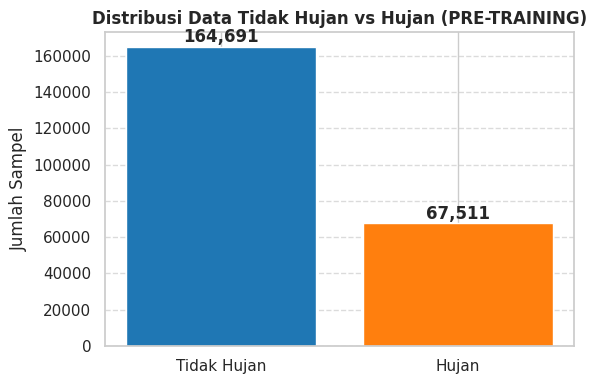

In [5]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (PRE-TRAINING)
# Memplot persentase kejadian hujan (rainrate >= 0.2 mm/jam) untuk mendeteksi ketidakseimbangan kelas (class imbalance).
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Tidak Hujan vs Hujan (PRE-TRAINING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

Sel ini meramu data mentah 1-jaman menjadi format 1-jaman yang siap ditelan model. Fitur-fitur canggih seperti **Tren 1 Jam** (*difference*) dihitung di sini, beserta nilai agregasi fitur konvektif tingkat lanjut (CAPE, K-Index) dari ERA5.

In [6]:
# Sel 5: Rekayasa Fitur Fisika Atmosfer
# Membuat fitur meteorologi penunjang seperti indeks diurnal (sin/cos jam) dan musiman,
# serta selisih titik embun (dewpoint depression) untuk mengidentifikasi tingkat kejenuhan udara.
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    lag_vars = ['rainrate', 'temperature', 'humidity', 'pressure', 'dewpoint','era5_cloud_cover']
    lags = [1, 3, 6, 12, 24]
    for var in lag_vars:
        if var in df_base.columns:
            for lag in lags:
                df_base[f'{var}_lag_{lag}h'] = df_base[var].shift(lag)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


## Tahap 5: Pelatihan Klasifikasi Hujan (Optuna)

Di sini model dilatih untuk mengenali apakah curah hujan akan mencapai ambang batas atau tidak. Sistem menggunakan algoritma pencarian cerdas **Optuna** untuk mencari kombinasi parameter terbaik.

2026-07-16 05:32:12,406 - INFO - 
MEMULAI OPTIMASI XGBOOST 3-JAM
2026-07-16 05:32:12,409 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-16 05:32:12,756 - INFO - Dimensi akhir setelah rekayasa fitur: (232157, 53)
2026-07-16 05:32:12,890 - INFO - Distribusi Split - Train: 140233, Val: 26242, Test: 17514
2026-07-16 05:32:12,891 - INFO - XGBoost device yang digunakan: cuda
[I 2026-07-16 05:32:15,517] A new study created in RDB with name: xgb_classifier
[I 2026-07-16 05:32:39,663] Trial 0 finished with value: 0.9446484953927444 and parameters: {'max_depth': 8, 'learning_rate': 0.007462026318901779, 'n_estimators': 799, 'subsample': 0.8488600602480494, 'colsample_bytree': 0.8010035960450218, 'gamma': 2.7889864588079156, 'min_child_weight': 42, 'reg_alpha': 1.4226173216041403e-08, 'reg_lambda': 0.049743998590824394}. Best is trial 0 with value: 0.9446484953927444.
[I 2026-07-16 05:32:45,768] Trial 1 finished with value: 0.9445811213259097 and parameters: {'max_depth': 9, 'learning_

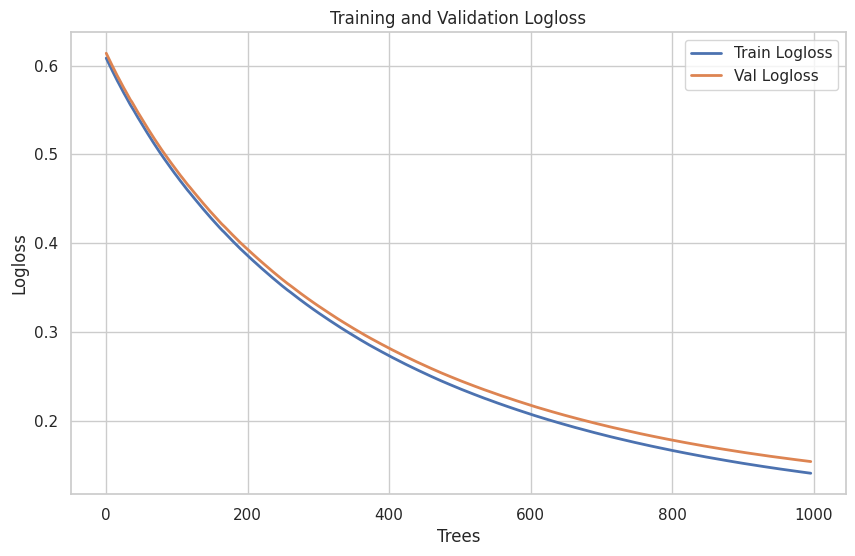

2026-07-16 05:55:13,713 - INFO - Plotly/Kaleido tidak tersedia, melewatkan optimization_history grafis optuna.
2026-07-16 05:55:14,189 - INFO - [Calibrator Selection] Brier scores - Raw: 0.0327, Platt: 0.0295, Isotonic: 0.0282
2026-07-16 05:55:14,191 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-16 05:55:14,207 - INFO - Best trial parameters: {'max_depth': 13, 'learning_rate': 0.0019441492067218424, 'n_estimators': 997, 'subsample': 0.5004575285203969, 'colsample_bytree': 0.9357205223111257, 'gamma': 4.881821858623471, 'min_child_weight': 10, 'reg_alpha': 0.0023807034968960383, 'reg_lambda': 2.021014031126626e-08}
2026-07-16 05:55:14,213 - INFO - Best classification F1-Score: 0.9452
2026-07-16 05:55:14,214 - INFO - Optimal Threshold Found from Best Trial: 0.50


Dataset Distribution (Pretraining)
Training samples: 140233
Validation samples: 26242
Testing samples: 17514
Rain samples: 55524
Non-rain samples: 128465
Rain percentage: 30.18%
Non-rain percentage: 69.82%
Positive/Negative ratio: 0.4322


In [7]:
# Sel 6: Setup & XGBoost Classifier Optuna
# Mengoptimalkan hyperparameter XGBoost Classifier pada tahap pertama Hurdle model.
# Menggunakan pencarian threshold dinamis untuk memaksimalkan potensi F1-Score pada data imbalanced.
import xgboost as xgb
import numpy as np
import os
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import f1_score

logger.info(f"\n{'='*50}\nMEMULAI OPTIMASI XGBOOST 3-JAM\n{'='*50}")
evaluator = ModelEvaluator()

# 1. Feature Engineering
df_features = engineer_features(df_hourly)

# 2. Target Creation (Prediksi 3 jam ke depan)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# 3. Data Split
# 1. Tentukan rentang data
if RUN_MODE == "PIPELINE_TEST":
    # Logika posisi untuk pengujian cepat
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.7)
    val_mask = (np.arange(n) >= int(n * 0.7)) & (np.arange(n) < int(n * 0.9))
    test_mask = np.arange(n) >= int(n * 0.9)
else:
    train_mask = (df_features.index >= PRETRAIN__TRAIN_START) & (df_features.index <= PRETRAIN__TRAIN_END)
    val_mask = (df_features.index >= PRETRAIN__VAL_START) & (df_features.index < PRETRAIN__VAL_END)
    test_mask = (df_features.index >= PRETRAIN__TEST_START) & (df_features.index <= PRETRAIN__TEST_END)

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

# Sel 6 (Bagian Data Split)
X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Distribusi Split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# Deteksi device GPU untuk Kaggle/Lokal
device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'
logger.info(f"XGBoost device yang digunakan: {device_xgb}")

# --- STAGE 1: CLASSIFIER OPTIMIZATION ---
def objective_occ(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 20, 1000),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),  
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state': SEED,
        'tree_method': 'hist',
        'device': device_xgb,
        'early_stopping_rounds': 30
    }
    clf = xgb.XGBClassifier(**params)
    clf.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], verbose=False)
    val_prob = clf.predict_proba(X_val)[:, 1]
    
    # --- PERBAIKAN: DYNAMIC THRESHOLD SEARCH ---
    best_f1 = 0
    best_thresh = 0.5
    
    # Iterasi untuk mencari ambang batas probabilitas terbaik pada data validasi
    for thresh in np.arange(0.20, 0.60, 0.02):
        val_preds = (val_prob >= thresh).astype(int)
        score = f1_score(y_val_occ, val_preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    # Menyimpan nilai threshold optimal dari trial ini ke dalam metadata Optuna
    trial.set_user_attr("best_threshold", best_thresh)
    
    return best_f1

optuna.logging.set_verbosity(optuna.logging.INFO)
db_path = evaluator.dirs['models'] / 'optuna_xgboost.db'
os.makedirs(db_path.parent, exist_ok=True)
storage_url = f"sqlite:///{db_path.as_posix()}"
study_occ = optuna.create_study(
    study_name="xgb_classifier",
    storage=storage_url,
    direction='maximize',
    load_if_exists=True
)
study_occ.optimize(objective_occ, n_trials=OPTUNA_TRIALS)

# Melatih Classifier Terbaik
best_params_occ = study_occ.best_params
best_params_occ.update({
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'random_state': SEED,
    'tree_method': 'hist',
    'device': device_xgb,
    'early_stopping_rounds': 10
})
clf_best = xgb.XGBClassifier(**best_params_occ)
# Sertakan train & val set agar logloss kedua set direkam untuk kurva evaluasi
clf_best.fit(X_train, y_train_occ, eval_set=[(X_train, y_train_occ), (X_val, y_val_occ)], verbose=False)

# Evaluasi Kurva Loss Classifier (Menampilkan baik Train maupun Validation Logloss)
results_clf = clf_best.evals_result()
plt.figure(figsize=(10,6))
plt.plot(results_clf['validation_0']['logloss'], label='Train Logloss')
plt.plot(results_clf['validation_1']['logloss'], label='Val Logloss')
plt.title('Training and Validation Logloss')
plt.ylabel('Logloss')
plt.xlabel('Trees')
plt.legend()
plt.savefig(evaluator.dirs['plots'] / 'validation_logloss.png', dpi=300)
plt.show()
plt.close()

# Plot Optimization History Optuna
try:
    fig = optuna.visualization.plot_optimization_history(study_occ)
    fig.write_image(str(evaluator.dirs['plots'] / 'optimization_history.png'))
except:
    logger.info("Plotly/Kaleido tidak tersedia, melewatkan optimization_history grafis optuna.")

joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ.pkl')

# Memilih Kalibrator Terbaik Secara Dinamis Menggunakan Data Validasi
calibrator_best, calibrator_type = fit_best_calibrator(y_val_occ.values, clf_best.predict_proba(X_val)[:, 1])

# --- TAMBAHAN LOG UNTUK THRESHOLD TERBAIK ---
best_threshold_found = study_occ.best_trial.user_attrs.get("best_threshold", 0.5)
logger.info(f"Best trial parameters: {study_occ.best_params}")
logger.info(f"Best classification F1-Score: {study_occ.best_value:.4f}")
logger.info(f"Optimal Threshold Found from Best Trial: {best_threshold_found:.2f}")

joblib.dump((calibrator_best, calibrator_type), evaluator.dirs['models_cal'] / 'best_calibrator_pretrain.pkl')
cek_proporsi_pretraining(X_train, y_train_occ, X_val, y_val_occ, X_test, y_test_occ)

# Simpan salinan split pre-trained sebelum ditimpa di fase fine-tuning
X_test_pre = X_test.copy()
y_test_occ_pre = y_test_occ.copy()
y_test_reg_pre = y_test_reg.copy()

## Tahap 6: Pelatihan Regresi Intensitas (Optuna)

Setelah model tahu bahwa akan turun hujan, model *Regressor* ini bertugas menebak **Berapa lebat hujannya?** (dalam satuan milimeter). Hanya wilayah dengan probabilitas hujan tinggi yang dilatih di tahap ini.

In [8]:
# Sel 7: XGBoost Regressor Optuna
# Mengoptimalkan hyperparameter XGBoost Regressor untuk menebak intensitas hujan pada tahap kedua Hurdle model.
# Pelatihan hanya dilakukan pada data dengan intensitas hujan positif (y_train_occ == 1) menggunakan loss squarederror.
# --- STAGE 2: REGRESSOR OPTIMIZATION ---
rainy_mask_train = y_train_occ == 1
rainy_mask_val = y_val_occ == 1
X_train_r, y_train_r = X_train[rainy_mask_train], y_train_reg[rainy_mask_train]
X_val_r, y_val_r = X_val[rainy_mask_val], y_val_reg[rainy_mask_val]

device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'

if np.sum(rainy_mask_train) > 10:
    def objective_reg(trial):
        params = {
            'objective': 'reg:squarederror', # Menggunakan MSE agar model dihukum berat jika gagal menebak hujan lebat
            'eval_metric': 'rmse',
            'max_depth': trial.suggest_int('max_depth', 8, 15),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 20, 1000),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 10, 50),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),  
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True), 
            'random_state': SEED, 
            'tree_method': 'hist', 
            'device': device_xgb,
            'early_stopping_rounds': 30
        }
        reg = xgb.XGBRegressor(**params)
        reg.fit(X_train_r, y_train_r, eval_set=[(X_val_r, y_val_r)], verbose=False)
        preds = reg.predict(X_val_r)
        return mean_squared_error(y_val_r, preds)
        
    db_path = evaluator.dirs['models'] / 'optuna_xgboost.db'
    storage_url = f"sqlite:///{db_path.as_posix()}"
    study_reg = optuna.create_study(
        study_name="xgb_regressor",
        storage=storage_url,
        direction='minimize',
        load_if_exists=True
    )
    study_reg.optimize(objective_reg, n_trials=OPTUNA_TRIALS)
        
    best_params_reg = study_reg.best_params
    best_params_reg.update({
        'random_state': SEED,
        'tree_method': 'hist',
        'device': device_xgb,
        'early_stopping_rounds': 10
    })
    
    reg_best = xgb.XGBRegressor(**best_params_reg)
    reg_best.fit(X_train_r, y_train_r, eval_set=[(X_train_r, y_train_r), (X_val_r, y_val_r)], verbose=False)
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg.pkl')
    logger.info(f"Best regressor trial parameters: {study_reg.best_params}")
    logger.info(f"Best regressor MSE: {study_reg.best_value:.4f}")
            
    # RMSE Curves
    results_reg = reg_best.evals_result()
    plt.figure(figsize=(10,6))
    plt.plot(results_reg['validation_0']['rmse'], label='Train RMSE')
    plt.plot(results_reg['validation_1']['rmse'], label='Val RMSE')
    plt.title('Training and Validation RMSE')
    plt.legend()
    plt.savefig(evaluator.dirs['plots'] / 'regressor_learning_curve.png', dpi=300)
    plt.close()
else:
    logger.warning("Tidak cukup sampel hujan untuk melatih Regressor.")
    reg_best = None


[I 2026-07-16 05:55:14,399] A new study created in RDB with name: xgb_regressor
[I 2026-07-16 05:55:20,267] Trial 0 finished with value: 0.05815997155834227 and parameters: {'max_depth': 14, 'learning_rate': 0.01820622968664868, 'n_estimators': 316, 'subsample': 0.7360685717794575, 'colsample_bytree': 0.9651214552898614, 'gamma': 2.7962798970113596, 'min_child_weight': 10, 'reg_alpha': 9.746842716130472e-05, 'reg_lambda': 2.1064107655098378e-05}. Best is trial 0 with value: 0.05815997155834227.
[I 2026-07-16 05:55:24,530] Trial 1 finished with value: 0.06521670670930711 and parameters: {'max_depth': 15, 'learning_rate': 0.035479158784867904, 'n_estimators': 944, 'subsample': 0.7777858522112976, 'colsample_bytree': 0.7348725468025537, 'gamma': 1.5951547312787402, 'min_child_weight': 18, 'reg_alpha': 3.1447424315812806e-08, 'reg_lambda': 0.002287954916947125}. Best is trial 0 with value: 0.05815997155834227.
[I 2026-07-16 05:55:30,656] Trial 2 finished with value: 0.26680460918226884 and

## FASE 2: FINE-TUNING (Data Aktual Stasiun AWS)

**Tujuan:** Menyelaraskan model dengan kondisi iklim lokal.
Sel ini menukar sumber data dasar menjadi **data pengukuran asli dari Stasiun AWS**, sembari mempertahankan fitur Angin dan Konvektif yang dipinjam secara dinamis dari ERA5.

In [9]:
# Sel 8: Pemuatan Data Aktual Stasiun Bumi AWS (Fine-Tuning)
# Memuat data stasiun AWS lokal dan menggabungkannya dengan ERA5. Perintah df_merged.update(df_station)
# digunakan untuk menimpa kolom meteorologi ERA5 dengan data observasi AWS stasiun bumi.
# Sel 12: Pemuatan Data dan Penyatuan (Data Loading & Merge) untuk FINE-TUNING
import os
from pathlib import Path
import pandas as pd
import numpy as np

logger.info("Mendeteksi Environment & Memuat data stasional untuk Fine-Tuning...")

if os.path.exists('/kaggle/input'):
    import glob
    search_file = glob.glob('/kaggle/input/**/id-05_clear_data_hourly.csv', recursive=True)
    if search_file:
        STATION_FILE = Path(search_file[0])
        sat_search = glob.glob('/kaggle/input/**/ERA5_Hourly_All_Requested_Features_2000_2026.csv', recursive=True)
        if sat_search:
            SAT_DIR = Path(sat_search[0]).parent
        else:
            SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
    else:
        STATION_FILE = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Stasiun/id-05_clear_data_hourly.csv')
        SAT_DIR = Path('/kaggle/input/google-earth-engine-data/Google_Earth_Engine/Data_Satelit')
else:
    BASE_DATA_DIR = Path('D:/Github/Projek_Rainfall')
    STATION_FILE = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit' / 'id-05_clear_data_hourly.csv'
    SAT_DIR = BASE_DATA_DIR / 'Google_Earth_Engine' / 'Data_Satelit'

# 1. Memuat Data Stasiun AWS Lokal
df_station = pd.read_csv(STATION_FILE)
df_station['timestamp'] = pd.to_datetime(df_station['datetime_utc'], utc=True)
df_station = df_station.set_index('timestamp').sort_index()
# Hanya ambil kolom yang relevan dari AWS
cols_to_keep = ['temperature', 'humidity', 'pressure', 'dewpoint', 'rainrate']
df_station = df_station[cols_to_keep]

# 2. Memuat ERA5
df_era5 = pd.read_csv(SAT_DIR / 'ERA5_Hourly_All_Requested_Features_2000_2026.csv')
if 'datetime_utc' in df_era5.columns:
    df_era5['timestamp'] = pd.to_datetime(df_era5['datetime_utc'], utc=True)
else:
    df_era5['timestamp'] = pd.to_datetime(df_era5['unixtime'], unit='s', utc=True)
df_era5 = df_era5.set_index('timestamp').sort_index()

df_merged = df_era5.copy()

# Pemetaan Variabel menggunakan Konfigurasi Global
for raw_col, new_name in ERA5_FEATURES_MAPPING.items():
    if raw_col in df_era5.columns:
        df_merged[new_name] = df_era5[raw_col]

# Hapus noise drizzle efek ERA5 (WMO wet-day threshold 0.1 mm/h)
if 'rainrate' in df_merged.columns:
    df_merged['rainrate'] = np.where(df_merged['rainrate'] >= 0.1, df_merged['rainrate'], 0.0)

# Simpan hanya fitur yang dipetakan
selected_features = list(ERA5_FEATURES_MAPPING.values())
df_merged = df_merged[[c for c in selected_features if c in df_merged.columns]]

# [REPLACEMENT AWS]
# Gabungkan dengan AWS. Di mana AWS ada, timpa ERA5!
df_merged.update(df_station)

# Potong dataset mulai 2025 (AWS hanya ada 2025-2026)
df_merged = df_merged[df_merged.index >= '2024-12-01']

drop_subset = ['temperature'] if 'temperature' in df_merged.columns else None
df_hourly = df_merged.dropna(subset=drop_subset).copy() if drop_subset else df_merged.dropna().copy()
df_hourly = df_hourly.select_dtypes(include=[np.number])
logger.info(f"Dimensi data terpadu (FINE-TUNING): {df_hourly.shape}")


2026-07-16 06:00:04,047 - INFO - Mendeteksi Environment & Memuat data stasional untuk Fine-Tuning...
2026-07-16 06:00:06,086 - INFO - Dimensi data terpadu (FINE-TUNING): (13778, 13)


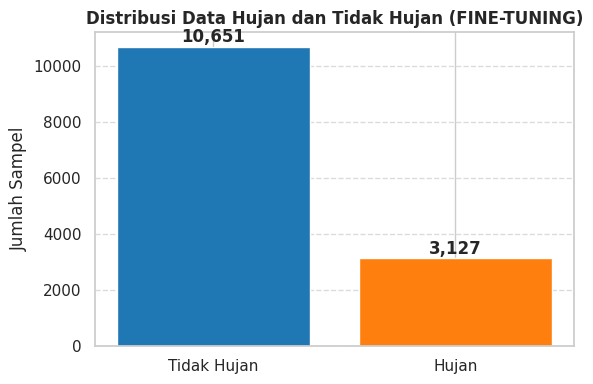

In [10]:
# Visualisasi Distribusi Hujan vs Tidak Hujan (FINE-TUNING)
# Memantau ketidakseimbangan kejadian hujan pada data stasiun bumi AWS lokal.
import matplotlib.pyplot as plt
import seaborn as sns

rain_count = (df_hourly['rainrate'] > 0).sum()
no_rain_count = (df_hourly['rainrate'] == 0).sum()

plt.figure(figsize=(6, 4))
bars = plt.bar(['Tidak Hujan', 'Hujan'], [no_rain_count, rain_count], color=['#1f77b4', '#ff7f0e'])
plt.title('Distribusi Data Hujan dan Tidak Hujan (FINE-TUNING)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Sampel')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (yval * 0.005), f'{yval:,}', ha='center', va='bottom', fontweight='bold')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Inspeksi Data Fine-Tuning

Menampilkan struktur data, jumlah kolom, dan kelengkapan (*missing values*) dari data terpadu AWS sebelum masuk ke tahap *Feature Engineering*.

In [11]:
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 13778 entries, 2024-12-01 00:00:00+00:00 to 2026-06-28 05:00:00+00:00
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   temperature        13778 non-null  float64
 1   humidity           13778 non-null  float64
 2   dewpoint           13778 non-null  float64
 3   rainrate           13778 non-null  float64
 4   pressure           13778 non-null  float64
 5   era5_u_wind        13778 non-null  float64
 6   era5_v_wind        13778 non-null  float64
 7   era5_cloud_cover   13778 non-null  float64
 8   era5_cape          13778 non-null  float64
 9   era5_tcwv          13778 non-null  float64
 10  era5_moisture_div  13778 non-null  float64
 11  era5_direct_rad    13778 non-null  float64
 12  era5_sunshine      13778 non-null  float64
dtypes: float64(13)
memory usage: 1.5 MB


In [12]:
df_features.head(10)

,temperature,humidity,dewpoint,rainrate,pressure,era5_u_wind,era5_v_wind,era5_cloud_cover,era5_cape,era5_tcwv,...,dewpoint_lag_6h,dewpoint_lag_12h,dewpoint_lag_24h,era5_cloud_cover_lag_1h,era5_cloud_cover_lag_3h,era5_cloud_cover_lag_6h,era5_cloud_cover_lag_12h,era5_cloud_cover_lag_24h,target_amount,target_occurrence
timestamp,,,,,,,,,,,,,,,,,,,,,
2000-01-02 00:00:00+00:00,27.417963,86.283854,24.921991,0.000000,1007.205469,0.066127,-0.158881,0.981444,758.247192,56.471428,...,23.935724,24.582544,24.088159,0.998474,0.998474,0.992645,0.998535,0.997101,0.000000,0
2000-01-02 01:00:00+00:00,28.041772,79.139811,24.086816,0.000000,1007.907109,0.218242,-0.173999,0.980773,360.365356,56.744328,...,24.006891,24.617548,23.649225,0.981444,0.999237,0.957762,1.000000,0.996338,0.000000,0
2000-01-02 02:00:00+00:00,29.282220,74.666781,24.316858,0.000000,1007.746719,0.299277,0.190473,0.971373,559.132812,56.428085,...,23.902856,24.669641,23.940820,0.980773,0.998474,0.972045,0.999237,0.998474,0.000000,0
2000-01-02 03:00:00+00:00,30.333063,70.483760,24.363794,0.000000,1007.223047,0.089018,0.811132,0.965636,754.993896,56.026310,...,23.963525,24.147333,24.496057,0.971373,0.981444,0.998474,1.000000,1.000000,0.000000,0
2000-01-02 04:00:00+00:00,30.827753,68.533312,24.367822,0.000000,1006.828828,0.307084,1.171229,0.934537,910.800049,56.632156,...,24.372644,23.992975,24.255396,0.965636,0.980773,0.999237,0.997681,0.989135,0.272642,1
2000-01-02 05:00:00+00:00,30.861383,70.328000,24.832208,0.272642,1006.006172,1.352881,2.045646,0.973662,1175.275635,56.955036,...,24.582239,23.921869,24.001794,0.934537,0.971373,0.998474,0.998474,1.000000,1.370799,1
2000-01-02 06:00:00+00:00,31.263910,68.590261,24.797540,1.370799,1005.355391,1.151146,2.147299,0.998474,1306.541748,57.709724,...,24.921991,23.935724,24.386377,0.973662,0.965636,0.981444,0.992645,0.988983,2.768910,1
2000-01-02 07:00:00+00:00,31.091699,69.580485,24.873315,2.768910,1004.990781,-0.841326,1.006191,1.000000,1533.674805,58.367531,...,24.086816,24.006891,24.530939,0.998474,0.934537,0.980773,0.957762,0.964598,4.087441,1
2000-01-02 08:00:00+00:00,30.980402,69.461924,24.738458,4.087441,1005.123594,-0.403464,0.159741,1.000000,1757.741943,59.688576,...,24.316858,23.902856,24.515985,1.000000,0.973662,0.971373,0.972045,0.943082,5.076955,1


## Tahap 4: Rekayasa Fitur (*Feature Engineering*)

In [13]:
# Sel 9: Rekayasa Fitur Temporal Lag (Fine-Tuning)
# Menghitung lag temporal 1, 3, 6, 12, dan 24 jam untuk variabel meteorologi utama
# (rainrate, temperature, humidity, pressure, CAPE) untuk memproyeksikan persistensi cuaca.
def engineer_features(df_base):
    logger.info("Mengekstraksi fitur fisika & temporal...")
    
    cols_diff = ['temperature', 'dewpoint', 'pressure']
    for c in cols_diff:
        if c in df_base.columns:
            df_base[f'{c}_tendency_1h'] = df_base[c].diff()
        
    if 'temperature' in df_base.columns and 'dewpoint' in df_base.columns:
        df_base['dewpoint_depression'] = df_base['temperature'] - df_base['dewpoint']
        
    df_base['sin_hour'] = np.sin(2 * np.pi * df_base.index.hour / 24.0)
    df_base['cos_hour'] = np.cos(2 * np.pi * df_base.index.hour / 24.0)
    df_base['sin_month'] = np.sin(2 * np.pi * df_base.index.month / 12.0)
    df_base['cos_month'] = np.cos(2 * np.pi * df_base.index.month / 12.0)
    df_base['sin_doy'] = np.sin(2 * np.pi * df_base.index.dayofyear / 365.25)
    df_base['cos_doy'] = np.cos(2 * np.pi * df_base.index.dayofyear / 365.25)

    # Menambahkan fitur lag (1, 3, 6, 12, 24 jam) untuk 5 variabel meteorologi utama
    lag_vars = ['rainrate', 'temperature', 'humidity', 'pressure', 'dewpoint','era5_cloud_cover']
    lags = [1, 3, 6, 12, 24]
    for var in lag_vars:
        if var in df_base.columns:
            for lag in lags:
                df_base[f'{var}_lag_{lag}h'] = df_base[var].shift(lag)

    df = df_base.copy()
    df = df.dropna()
    logger.info(f"Dimensi akhir setelah rekayasa fitur: {df.shape}")
    return df


In [14]:
# Ekstraksi Fitur dan Pembuatan Target untuk Fine-Tuning
# Memisahkan fitur prediktor (X) dan target (y_occ, y_reg) serta membaginya ke dalam split latih, validasi, dan uji.
df_features = engineer_features(df_hourly)

# Target Creation (Prediksi 3 jam ke depan, persis seperti pre-training)
df_features['target_amount'] = df_features['rainrate'].shift(-1)
df_features = df_features.dropna()
df_features['target_occurrence'] = (df_features['target_amount'] >= RAIN_THRESHOLD).astype(int)

# [PEMBAGIAN DATA FINE-TUNING BERDASARKAN TANGGAL]
if RUN_MODE == "PIPELINE_TEST":
    n = len(df_features)
    train_mask = np.arange(n) < int(n * 0.6)
    val_mask = (np.arange(n) >= int(n * 0.6)) & (np.arange(n) < int(n * 0.8))
    test_mask = np.arange(n) >= int(n * 0.8)
else:
    train_mask = (df_features.index >= FINETUNE_TRAIN_START) & (df_features.index <= FINETUNE_TRAIN_END)
    val_mask = (df_features.index >= FINETUNE_VAL_START) & (df_features.index < FINETUNE_VAL_END)
    test_mask = (df_features.index >= FINETUNE_TEST_START) & (df_features.index <= FINETUNE_TEST_END)

X = df_features.drop(columns=['target_amount', 'target_occurrence'])
y_occ = df_features['target_occurrence']
y_reg = df_features['target_amount']

X_train, y_train_occ, y_train_reg = X[train_mask], y_occ[train_mask], y_reg[train_mask]
X_val, y_val_occ, y_val_reg = X[val_mask], y_occ[val_mask], y_reg[val_mask]
X_test, y_test_occ, y_test_reg = X[test_mask], y_occ[test_mask], y_reg[test_mask]

logger.info(f"Dimensi X_train (Fine-Tuning): {X_train.shape}")
logger.info(f"Dimensi X_val (Fine-Tuning): {X_val.shape}")
logger.info(f"Dimensi X_test (Fine-Tuning): {X_test.shape}")
cek_proporsi_finetuning(X_train, y_train_occ, X_val, y_val_occ, X_test, y_test_occ)


2026-07-16 06:00:06,498 - INFO - Mengekstraksi fitur fisika & temporal...
2026-07-16 06:00:06,529 - INFO - Dimensi akhir setelah rekayasa fitur: (13754, 53)
2026-07-16 06:00:06,544 - INFO - Dimensi X_train (Fine-Tuning): (9097, 53)
2026-07-16 06:00:06,545 - INFO - Dimensi X_val (Fine-Tuning): (1896, 53)
2026-07-16 06:00:06,547 - INFO - Dimensi X_test (Fine-Tuning): (1321, 53)


Dataset Distribution (Fine-Tuning)
Training samples: 9097
Validation samples: 1896
Testing samples: 1321
Rain samples: 2266
Non-rain samples: 10048
Rain percentage: 18.40%
Non-rain percentage: 81.60%
Positive/Negative ratio: 0.2255


## Tahap Terakhir: Proses Fine-Tuning & Perbandingan Model

Di tahap ini, model yang sudah pintar secara global di-*retrain* menggunakan dataset lokal (AWS). Sel ini juga mengaplikasikan **Isotonic Regression** untuk kalibrasi probabilitas, lalu menghasilkan laporan komparasi performa *Pre-trained* vs *Fine-tuned*.

In [15]:
# Sel 10: Proses Fine-Tuning (XGBoost)
# Melatih ulang model dasar (Classifier & Regressor) secara warm-start menggunakan data stasiun AWS,
# menyetel ulang kalibrator optimal pada data validasi fine-tuning.
import xgboost as xgb
import joblib
import numpy as np
import os

# Penyelarasan Urutan Fitur (Feature Alignment)
if hasattr(clf_best, 'feature_names_in_'):
    feature_order = clf_best.feature_names_in_
elif hasattr(clf_best, 'feature_names') and clf_best.feature_names is not None:
    feature_order = clf_best.feature_names
else:
    feature_order = clf_best.get_booster().feature_names

X_train = X_train[feature_order]
X_val = X_val[feature_order]
X_test = X_test[feature_order]
X = X[feature_order]

device_xgb = 'cuda' if os.path.exists('/kaggle/input') else 'cpu'

# 1. PROSES FINE-TUNING (Warm-Start / Update dengan Data AWS)
logger.info("Memulai Fine-Tuning XGBoost Classifier...")
clf_best.set_params(learning_rate=0.01, device=device_xgb)
clf_best.fit(X_train, y_train_occ, eval_set=[(X_val, y_val_occ)], xgb_model=clf_best.get_booster(), verbose=False)
joblib.dump(clf_best, evaluator.dirs['models_clf'] / 'best_xgb_occ_finetuned.pkl')

# Calibrator Re-fit menggunakan data validasi fine-tuning
val_probs_uncal = clf_best.predict_proba(X_val)[:, 1]
calibrator_post, calibrator_type_post = fit_best_calibrator(y_val_occ.values, val_probs_uncal)
joblib.dump((calibrator_post, calibrator_type_post), evaluator.dirs['models_cal'] / 'best_calibrator_finetuned.pkl')

if reg_best is not None and np.sum(y_train_occ == 1) > 10:
    logger.info("Memulai Fine-Tuning XGBoost Regressor...")
    reg_best.set_params(learning_rate=0.01, device=device_xgb)
    rainy_mask_tr = y_train_occ == 1
    rainy_mask_va = y_val_occ == 1
    reg_best.fit(X_train[rainy_mask_tr], y_train_reg[rainy_mask_tr], 
                 eval_set=[(X_val[rainy_mask_va], y_val_reg[rainy_mask_va])], 
                 xgb_model=reg_best.get_booster(), verbose=False)
    joblib.dump(reg_best, evaluator.dirs['models_reg'] / 'best_xgb_reg_finetuned.pkl')

logger.info("Fine-Tuning XGBoost Selesai!")


2026-07-16 06:00:06,630 - INFO - Memulai Fine-Tuning XGBoost Classifier...
2026-07-16 06:00:07,608 - INFO - [Calibrator Selection] Brier scores - Raw: 0.2069, Platt: 0.1885, Isotonic: 0.1781
2026-07-16 06:00:07,609 - INFO - [Calibrator Selection] Selected Isotonic Calibrator
2026-07-16 06:00:07,612 - INFO - Memulai Fine-Tuning XGBoost Regressor...
2026-07-16 06:00:08,697 - INFO - Fine-Tuning XGBoost Selesai!


# Bab 1: Evaluasi Model Pretraining
Dalam bab ini, model dasar yang dilatih hanya menggunakan data satelit (Pre-Trained) dievaluasi kinerjanya pada data uji aktual stasiun AWS bumi untuk melihat tingkat akurasi awal sebelum proses penyesuaian lokal.


2026-07-16 06:00:08,767 - INFO - Memulai Bab 1: Evaluasi Model Pretraining...
2026-07-16 06:00:09,075 - INFO - Menghitung metrik klasifikasi...


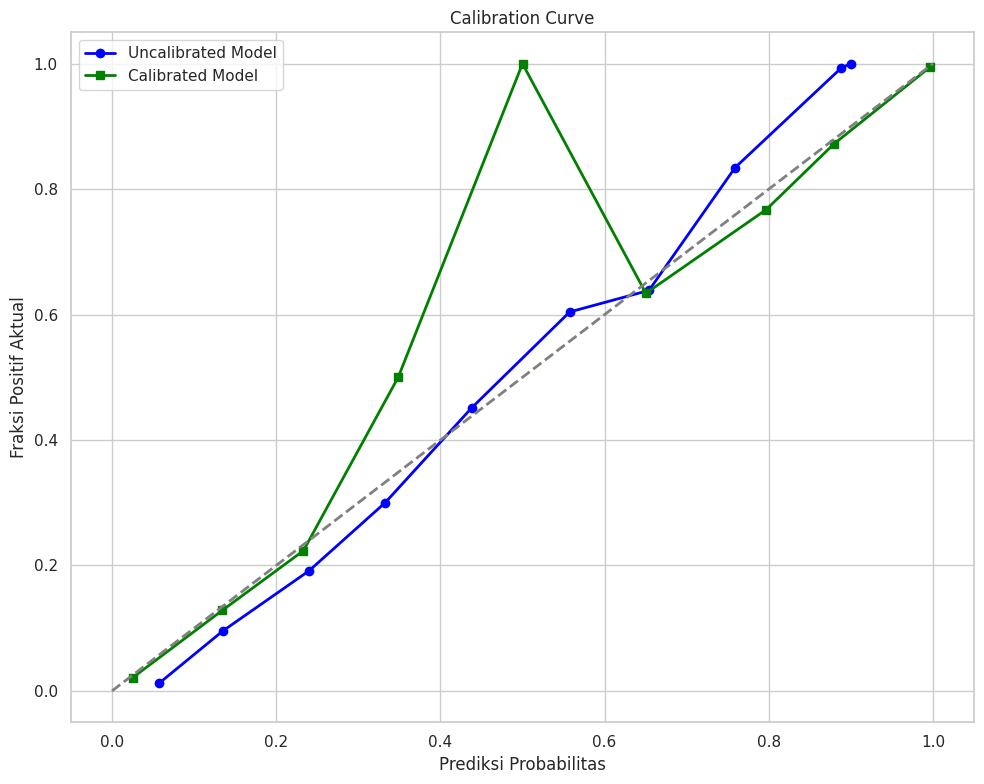

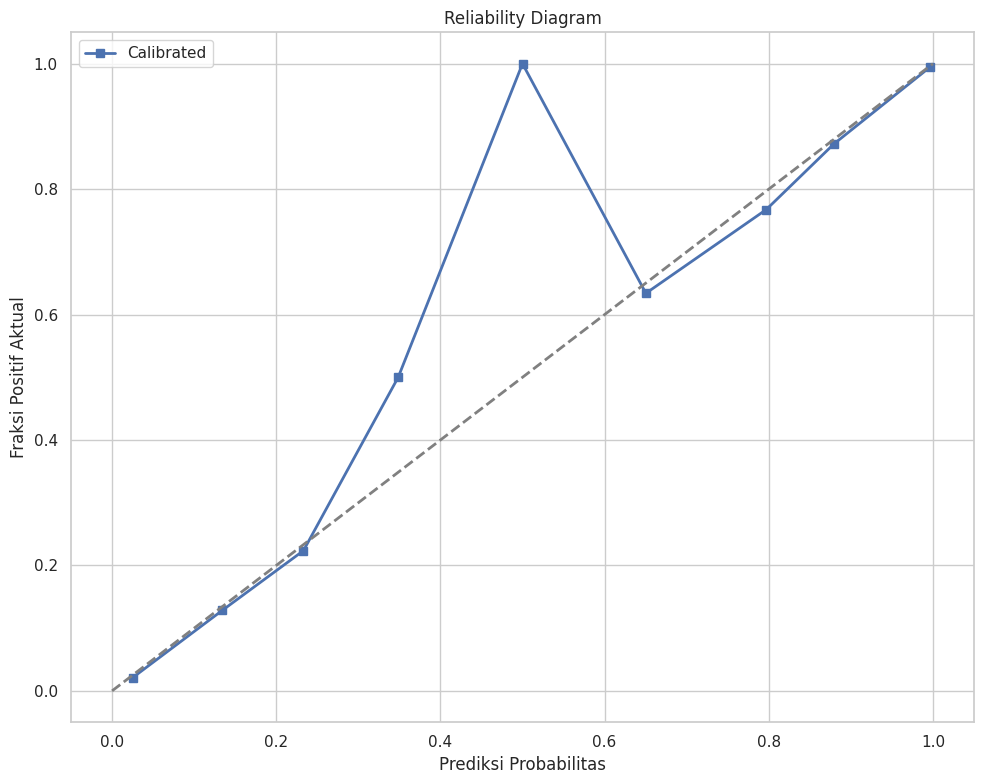

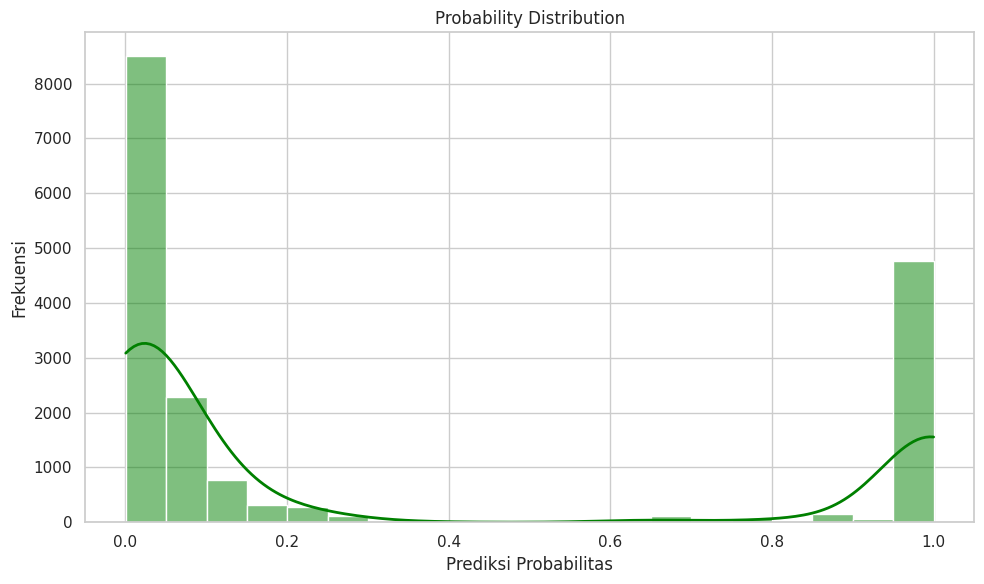

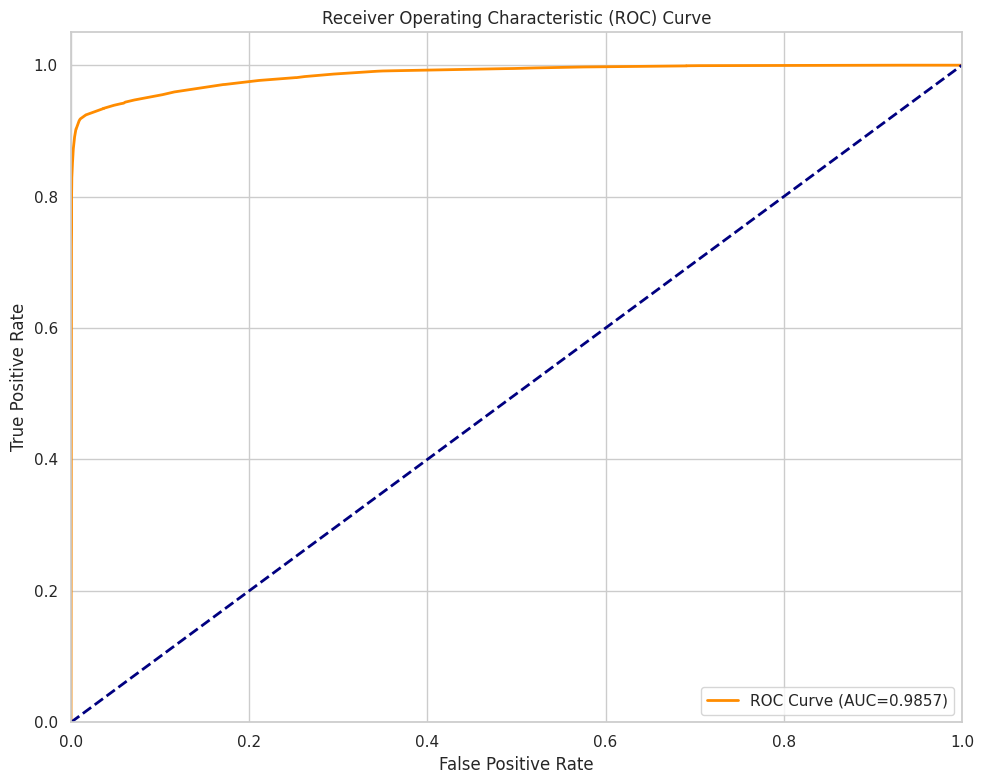

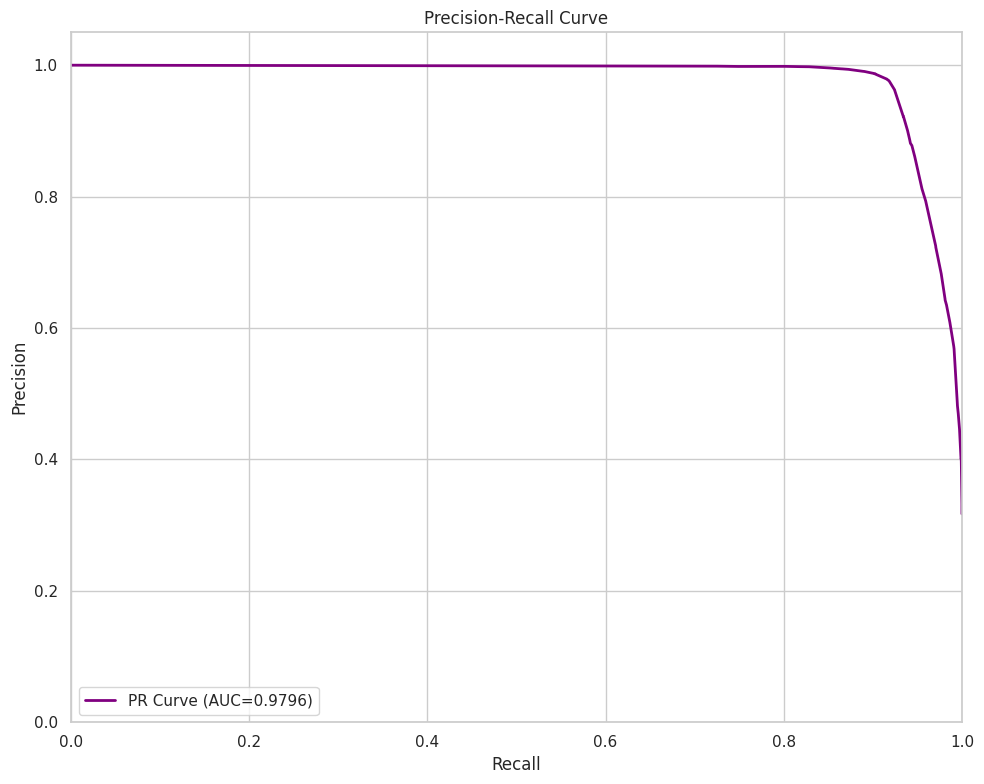

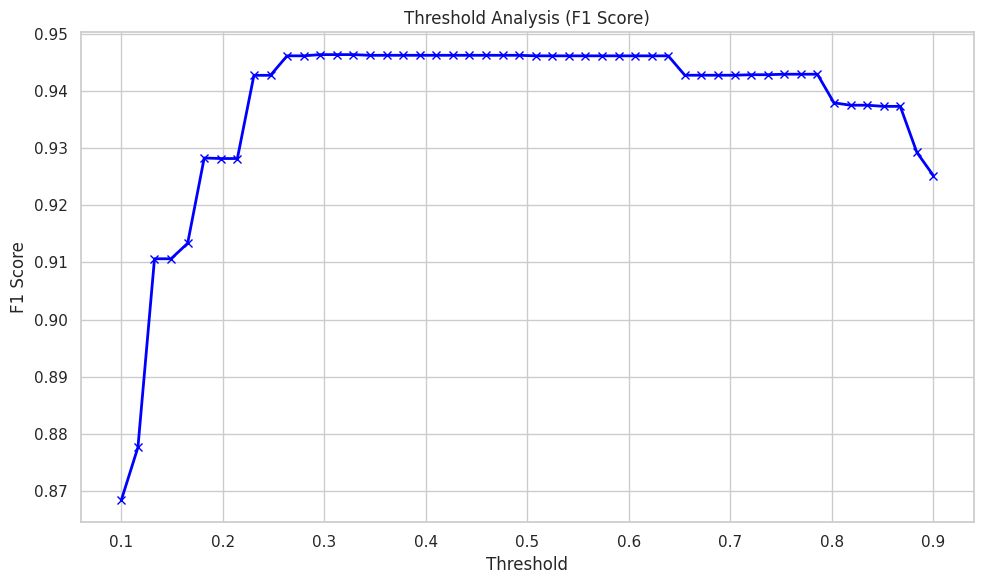

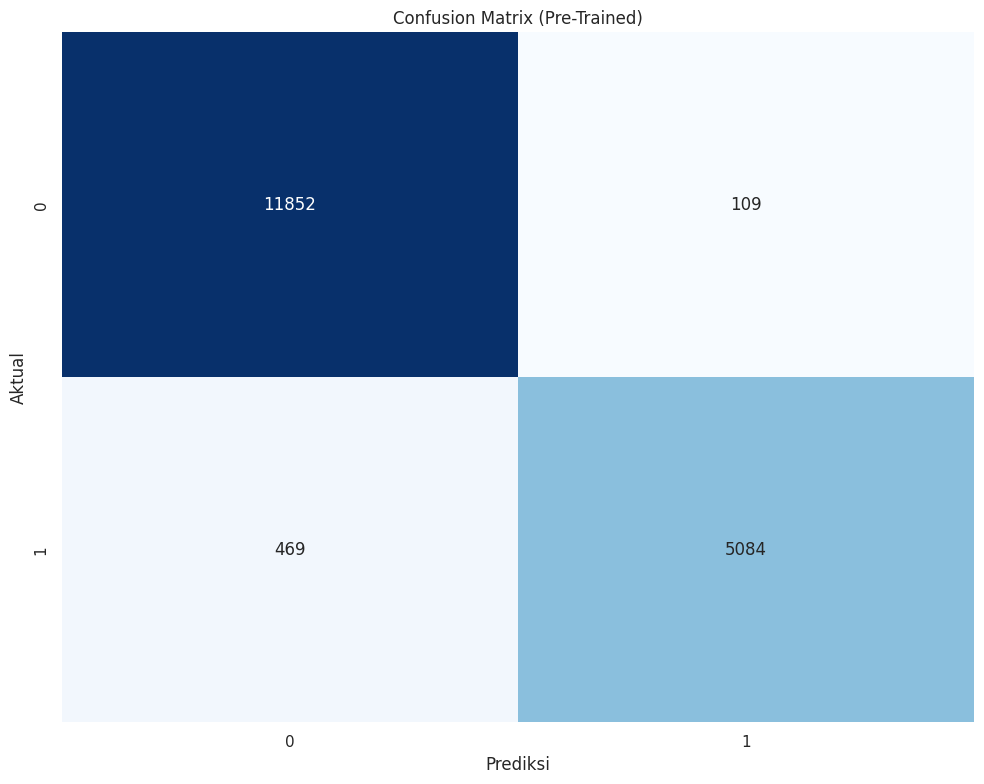

2026-07-16 06:00:14,761 - INFO - Menghitung metrik regresi...


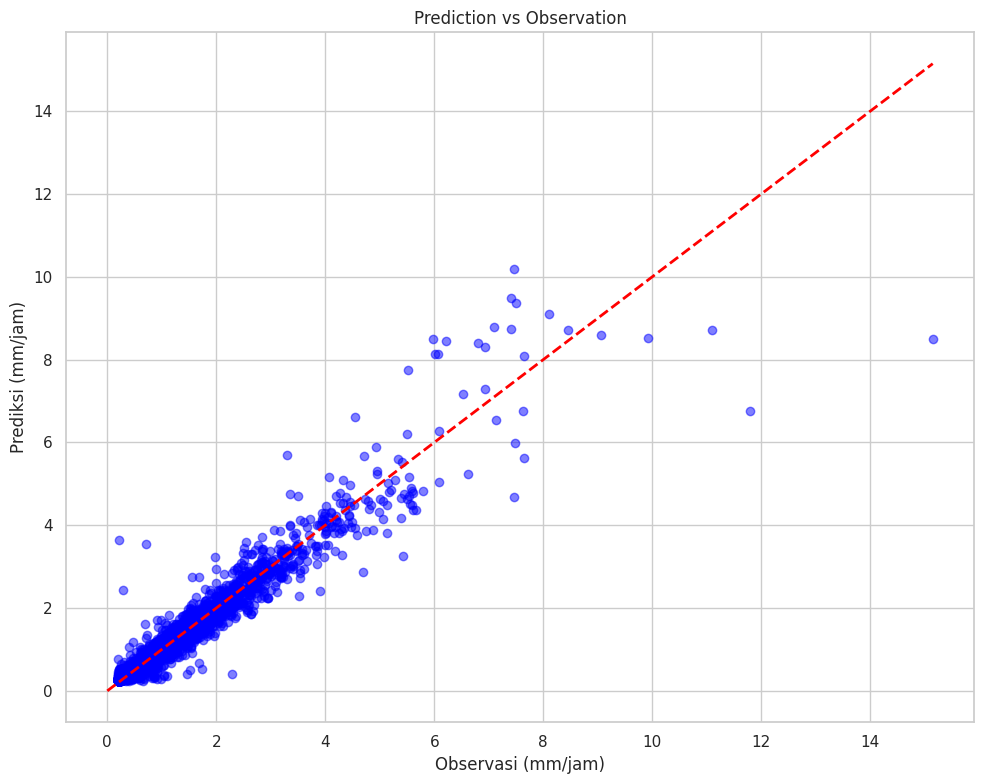

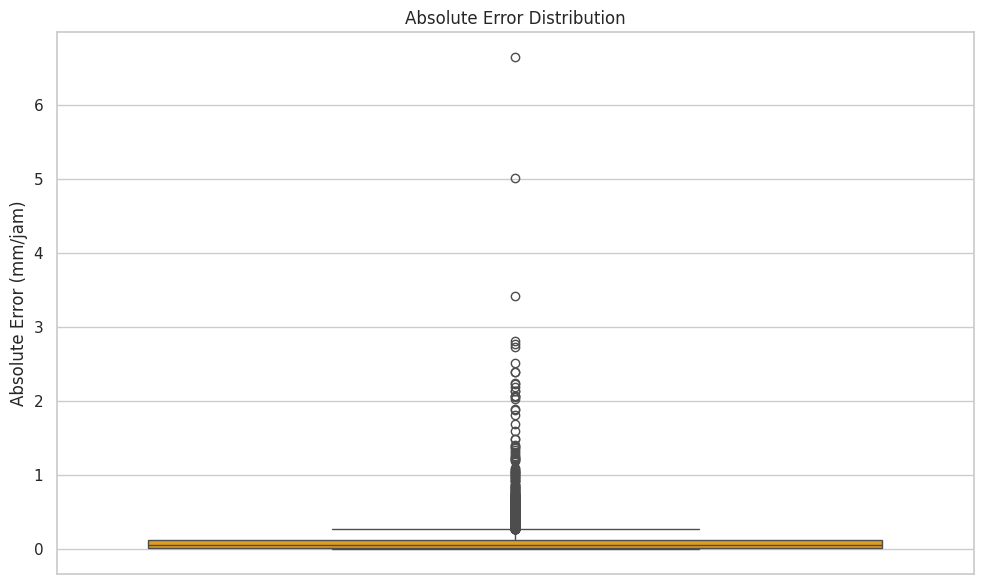

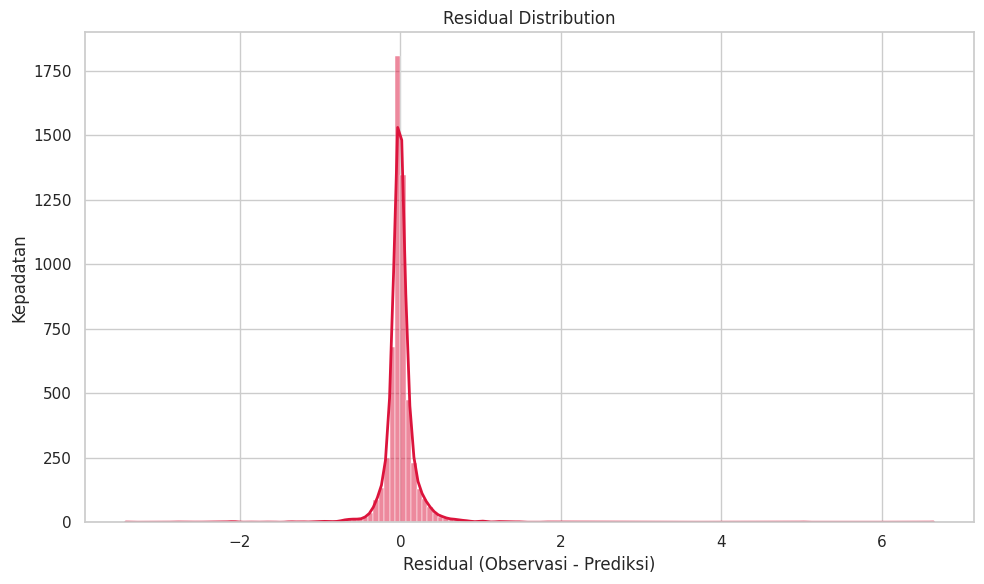

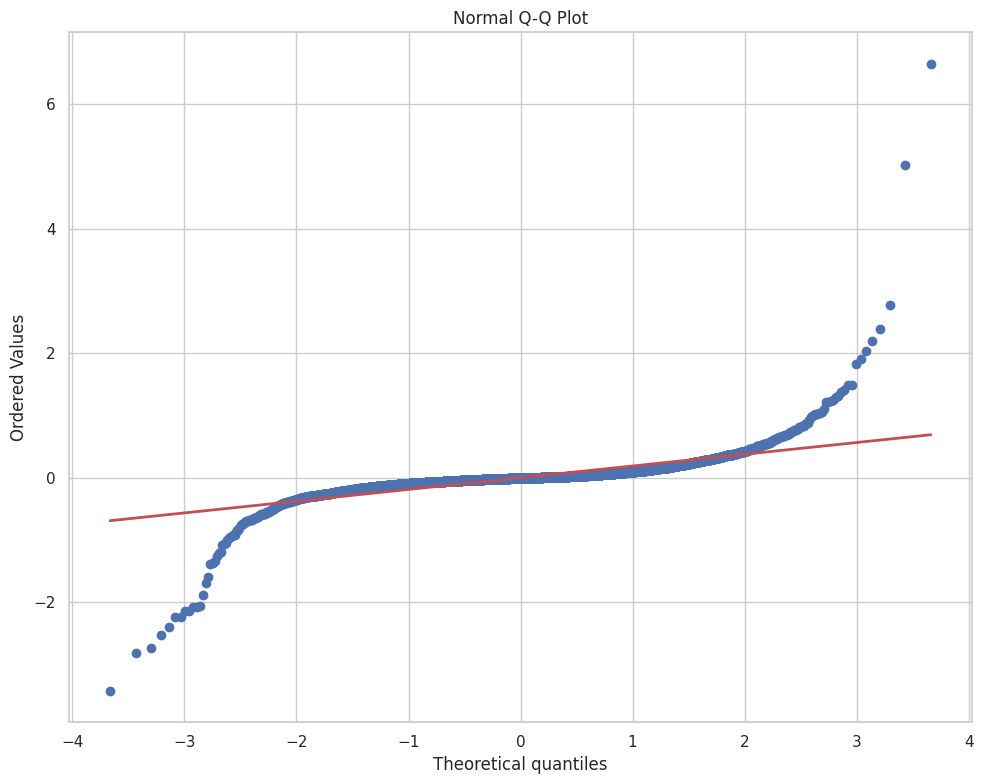

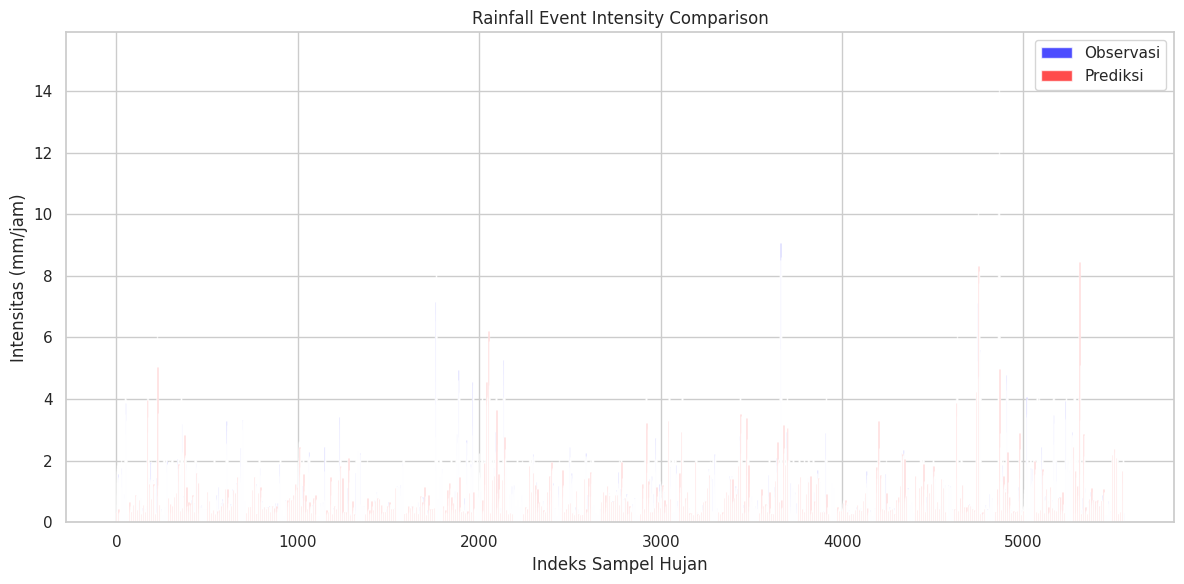

2026-07-16 06:00:43,002 - INFO - Evaluasi Model Pre-Trained Selesai!


In [16]:
# Bab 1: Evaluasi Model Pretraining (XGBoost)
logger.info("Memulai Bab 1: Evaluasi Model Pretraining...")
evaluator_pre = ModelEvaluator(BASE_OUTPUT_DIR, phase='pretraining')

# Load model pre-trained asli (satelit)
clf_pretrain = joblib.load(evaluator_pre.dirs['models_clf'] / 'best_xgb_occ.pkl')
reg_pretrain = joblib.load(evaluator_pre.dirs['models_reg'] / 'best_xgb_reg.pkl') if (evaluator_pre.dirs['models_reg'] / 'best_xgb_reg.pkl').exists() else None

# Pemuatan calibrator pre-train
calibrator_pre, cal_method_pre = joblib.load(evaluator_pre.dirs['models_cal'] / 'best_calibrator_pretrain.pkl')

# Prediksi Klasifikasi pada data uji satelit pre-training
pre_test_prob_uncal = clf_pretrain.predict_proba(X_test_pre)[:, 1]
pre_test_prob_cal = apply_calibrator(calibrator_pre, cal_method_pre, pre_test_prob_uncal)
pre_test_preds = (pre_test_prob_cal >= 0.5).astype(int)

# Prediksi Regresi (Hanya pada sampel hujan)
pre_test_preds_r_pre = np.zeros(len(y_test_occ_pre))
rainy_te_pre = y_test_occ_pre == 1
if reg_pretrain is not None and np.sum(rainy_te_pre) > 0:
    pre_test_preds_r_pre[rainy_te_pre] = reg_pretrain.predict(X_test_pre[rainy_te_pre])

# Jalankan Evaluasi Klasifikasi Pre-Trained
clf_metrics_pre, meteo_metrics_pre = evaluator_pre.evaluate_classification(
    y_test_occ_pre, pre_test_prob_uncal, pre_test_prob_cal, pre_test_preds
)
ece_pre, mce_pre = compute_ece_mce(y_test_occ_pre, pre_test_prob_cal)
clf_metrics_pre['ECE'] = ece_pre
clf_metrics_pre['MCE'] = mce_pre
evaluator_pre.save_combined_metrics()

# Simpan Confusion Matrix Pre-Trained
evaluator_pre.plot_confusion_matrix(y_test_occ_pre, pre_test_preds, filename='confusion_matrix.png', suffix='(Pre-Trained)')

# Jalankan Evaluasi Regresi Pre-Trained
if np.sum(rainy_te_pre) > 0:
    reg_metrics_pre = evaluator_pre.evaluate_regression(y_test_reg_pre[rainy_te_pre], pre_test_preds_r_pre[rainy_te_pre])
else:
    reg_metrics_pre = {}

# Buat Laporan Evaluasi Pre-Trained
evaluator_pre.generate_report(len(X_train), len(X_val), len(X_test_pre), X.columns.tolist(), clf_metrics_pre, meteo_metrics_pre, reg_metrics_pre, "XGBoost (Pre-Trained)")
logger.info("Evaluasi Model Pre-Trained Selesai!")


# Bab 2: Evaluasi Model Fine-Tuning
Dalam bab ini, model yang telah disetel ulang (*Fine-Tuned*) secara *warm-start* menggunakan data stasiun bumi AWS dievaluasi performanya pada data uji untuk membuktikan efek kalibrasi lokal.


2026-07-16 06:00:43,133 - INFO - Memulai Bab 2: Evaluasi Model Fine-Tuning...
2026-07-16 06:00:43,213 - INFO - Menghitung metrik klasifikasi...


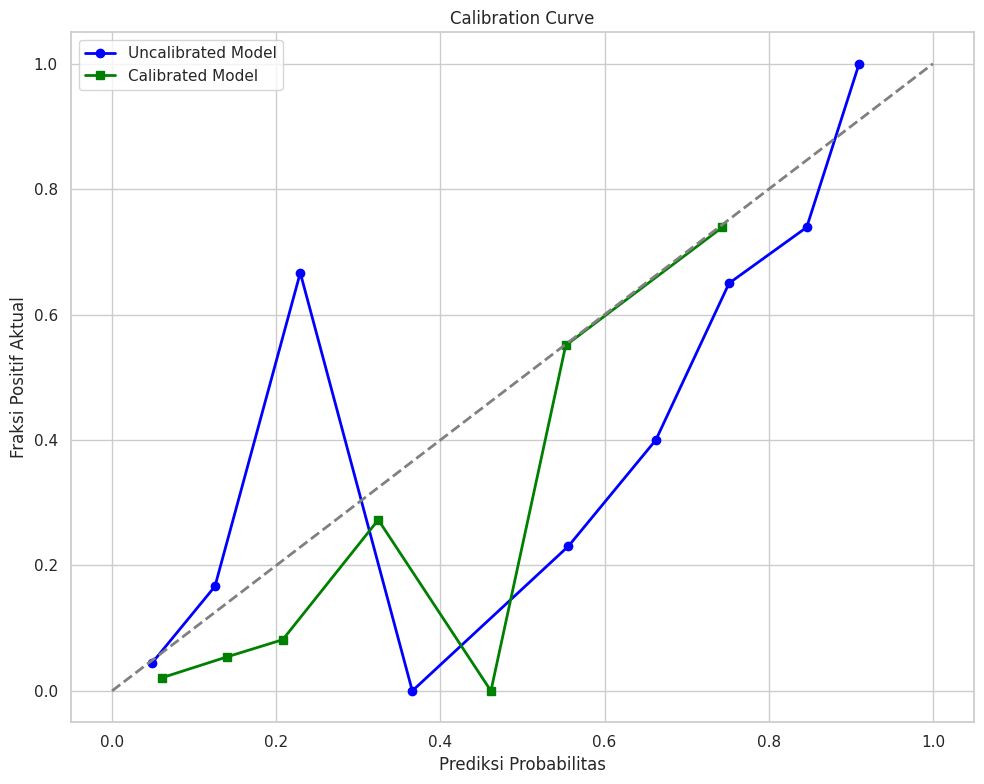

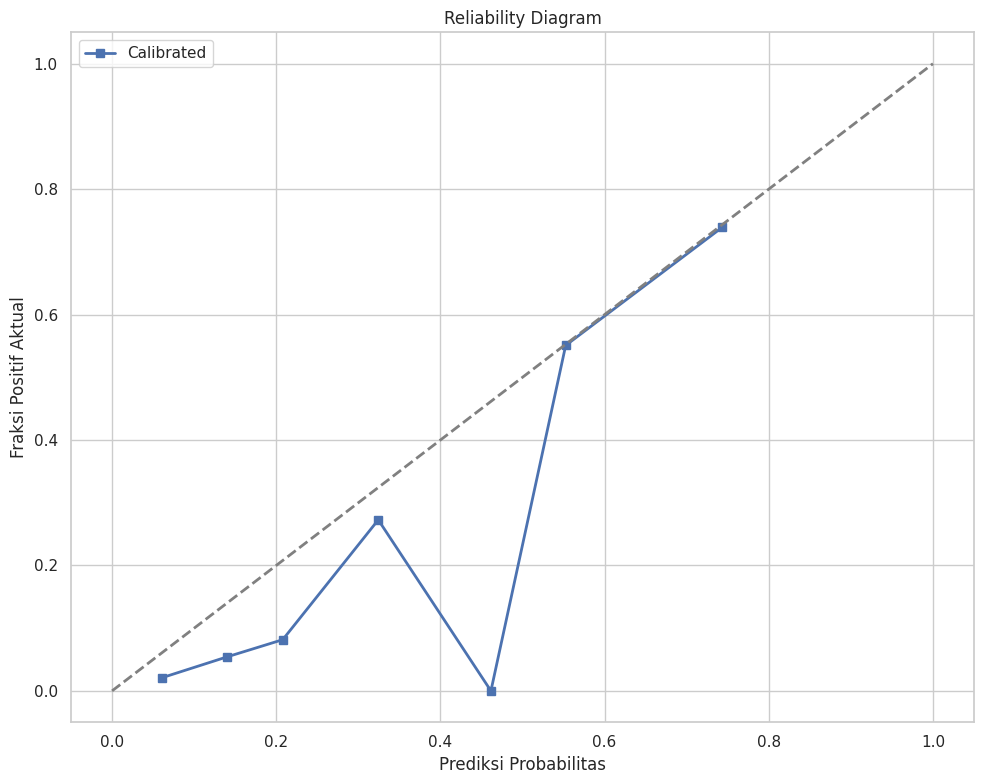

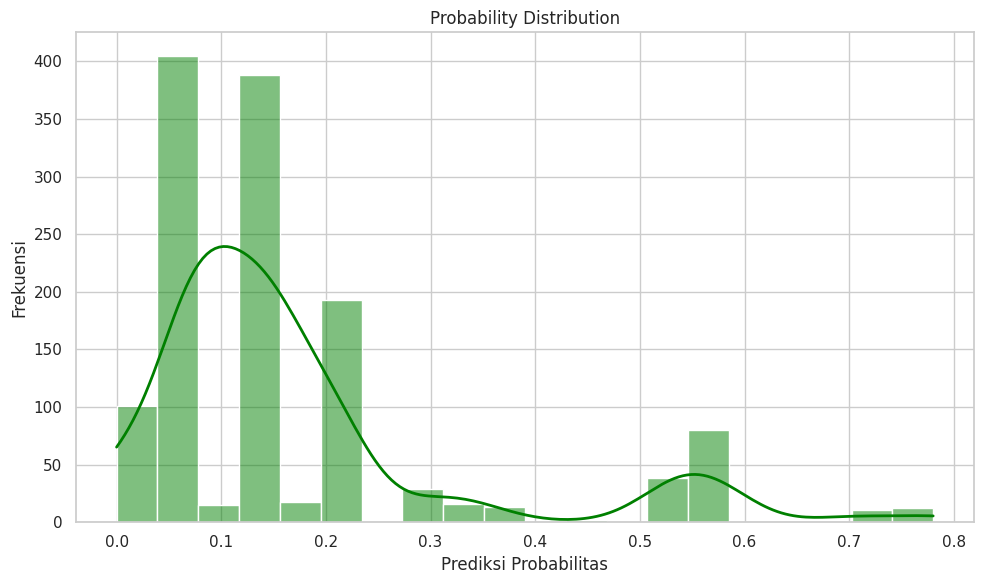

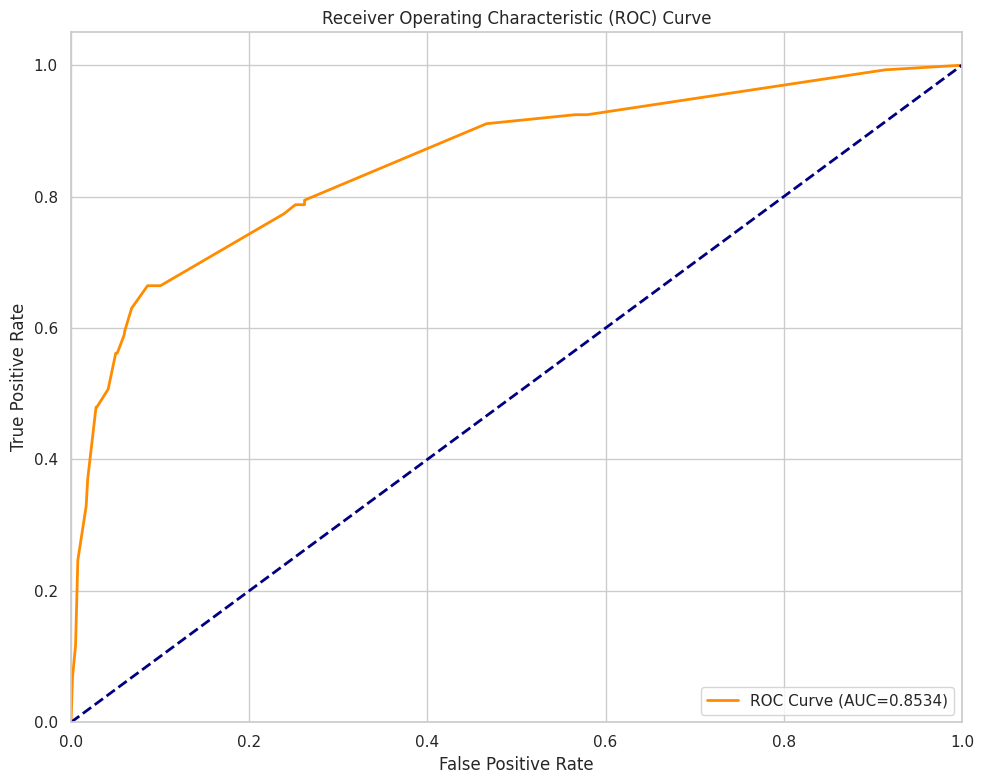

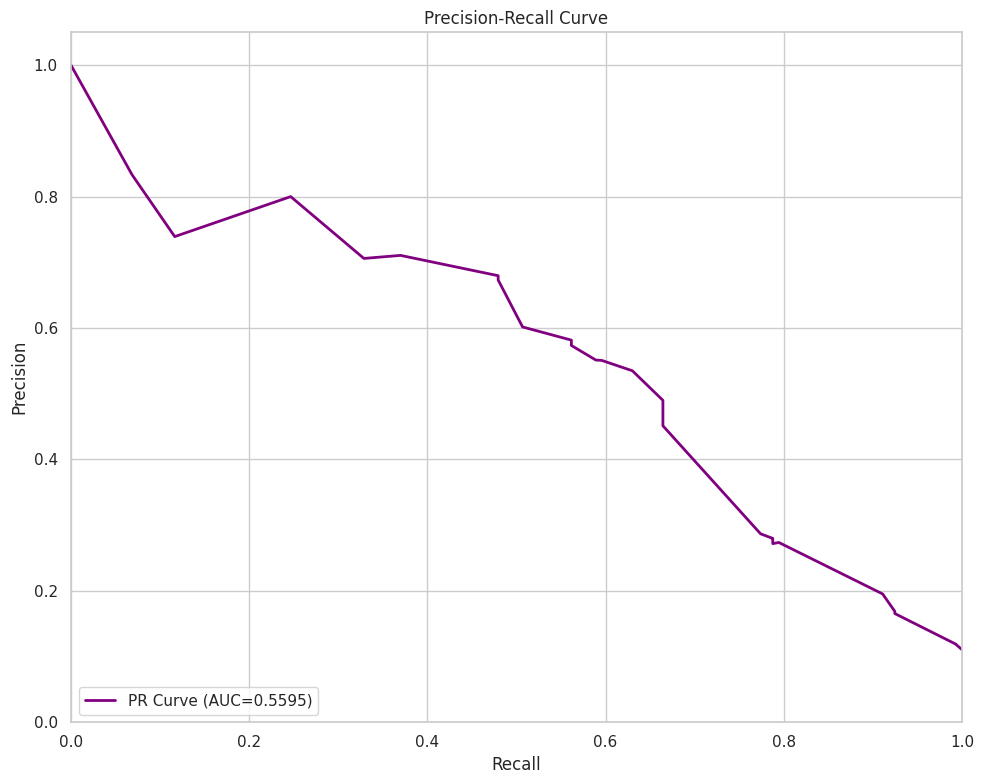

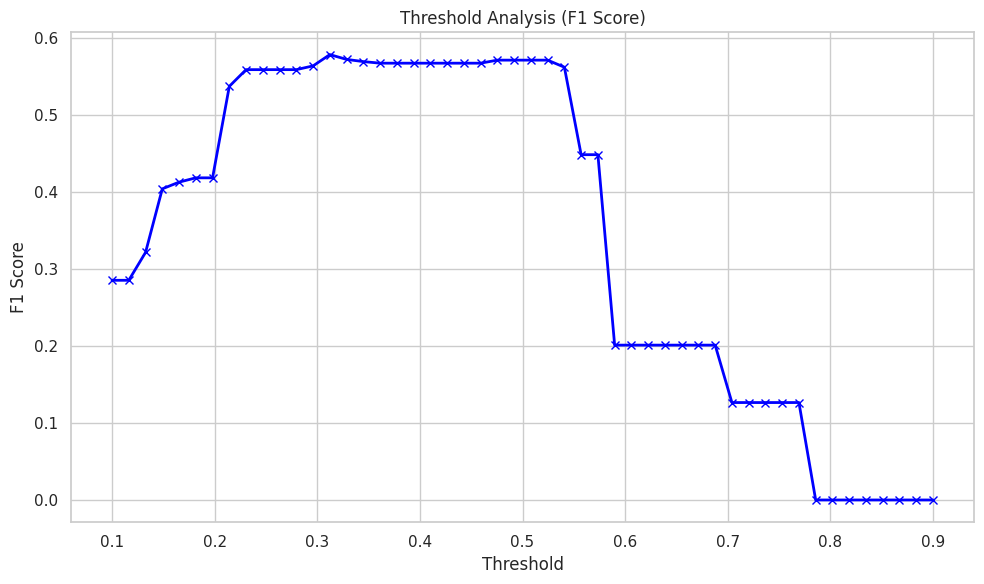

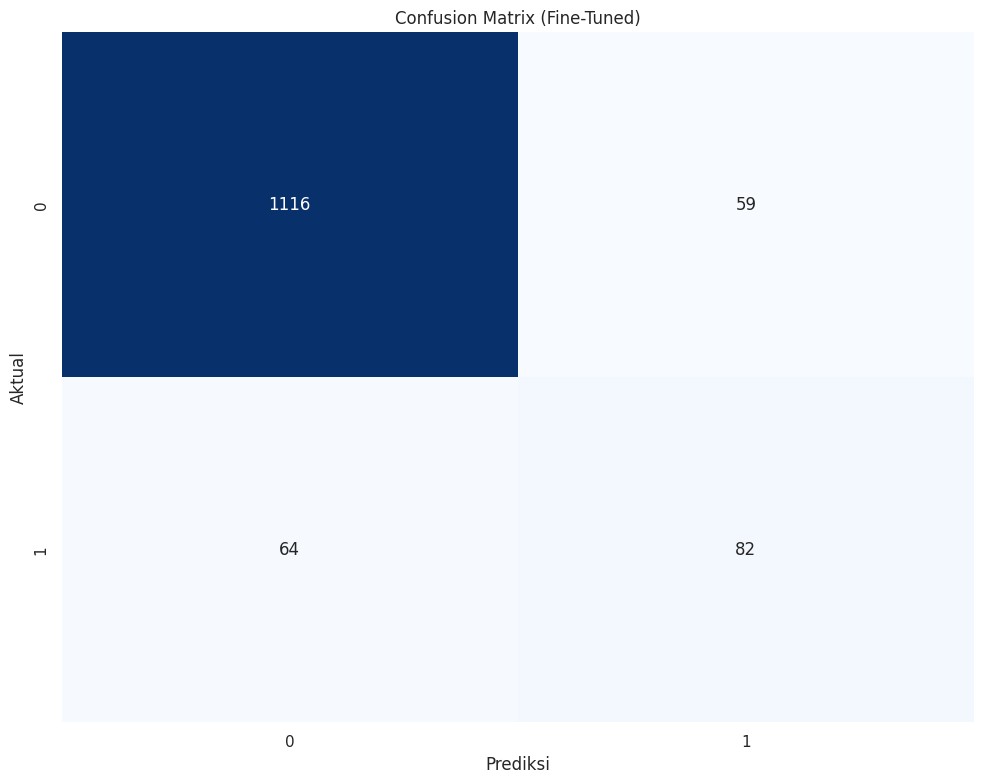

2026-07-16 06:00:48,528 - INFO - Menghitung metrik regresi...


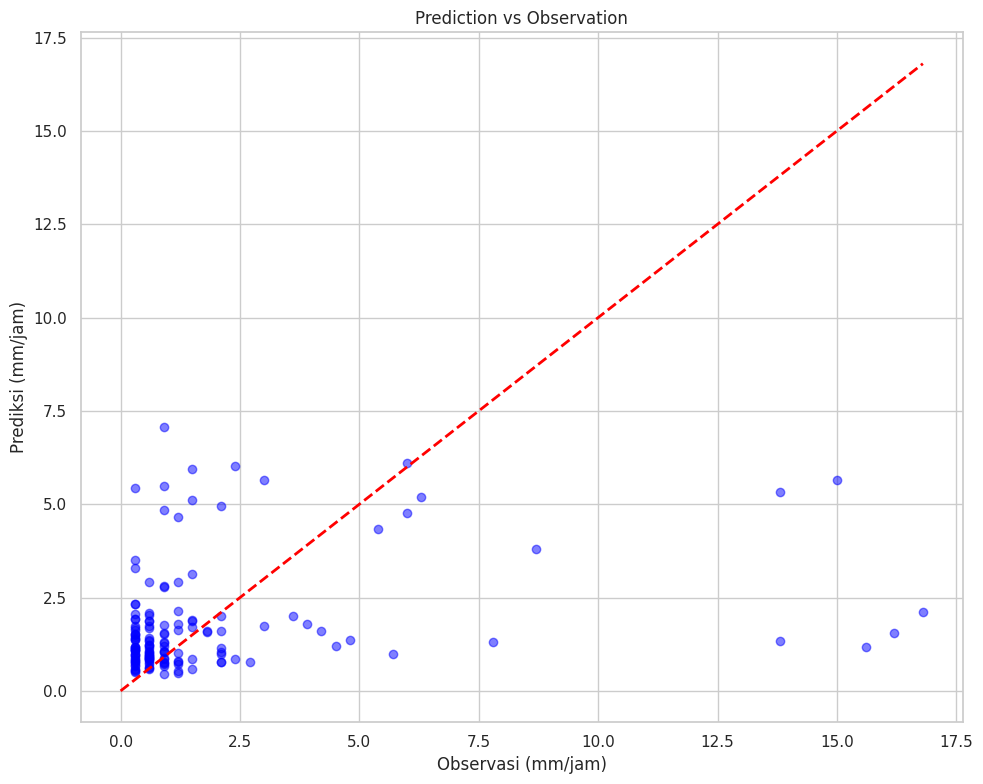

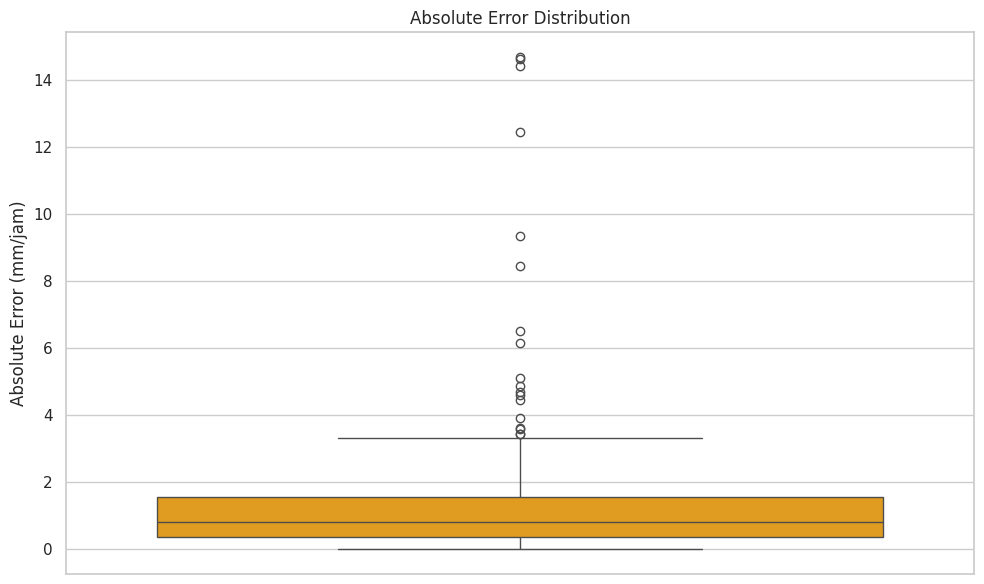

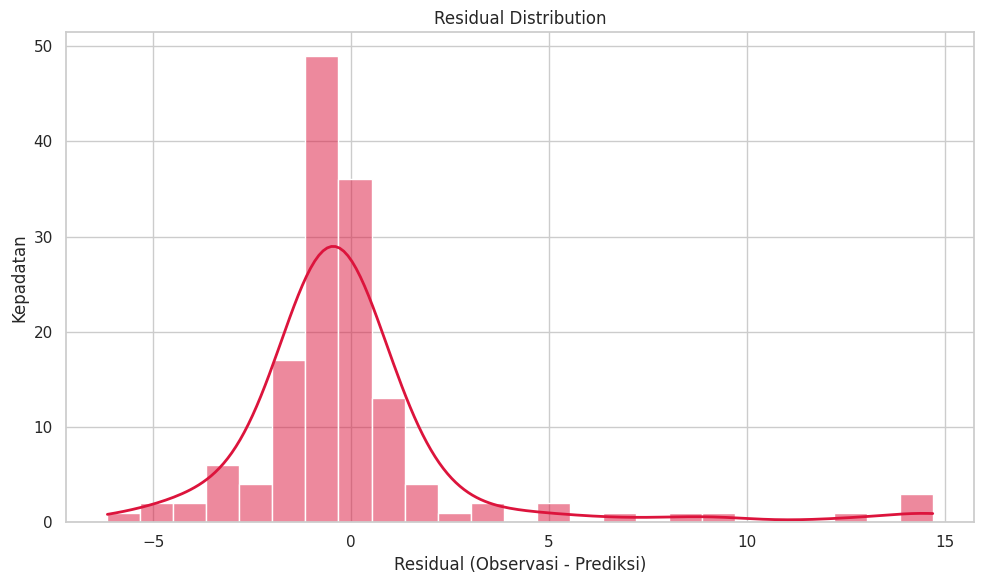

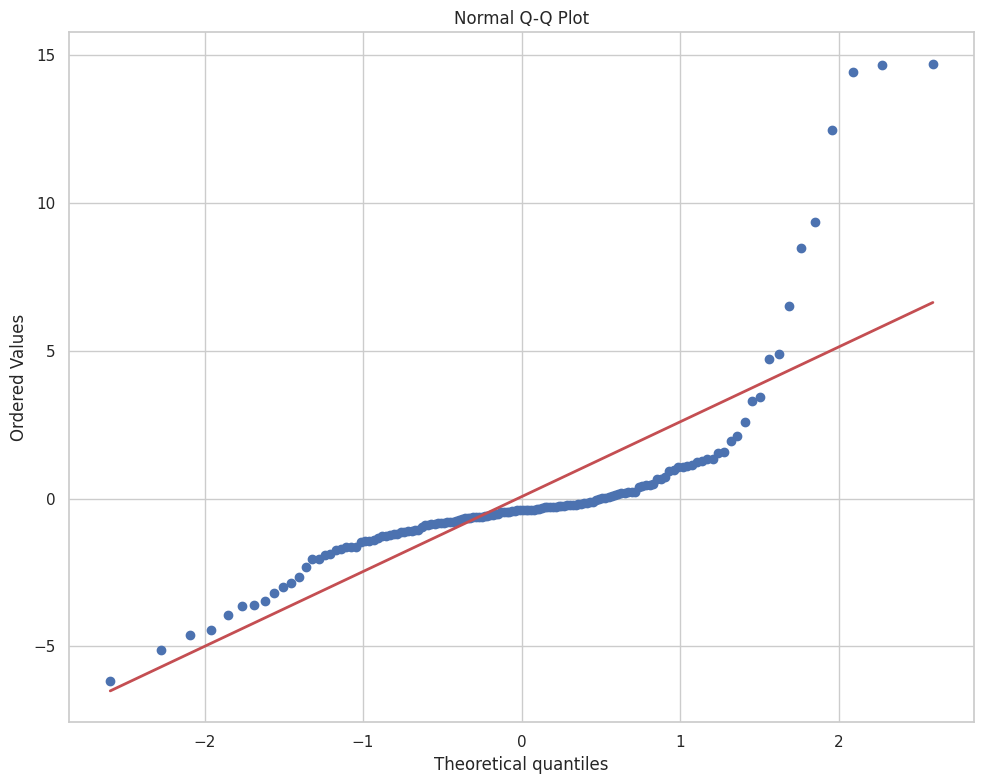

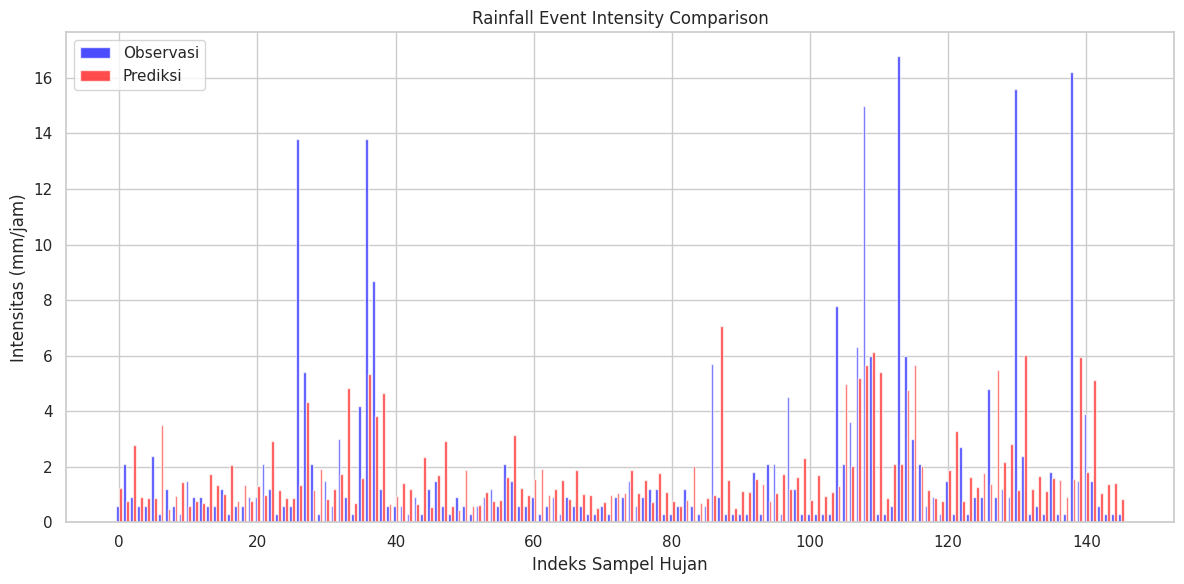

2026-07-16 06:00:52,793 - INFO - Evaluasi Model Fine-Tuned Selesai!


In [17]:
# Bab 2: Evaluasi Model Fine-Tuning (XGBoost)
logger.info("Memulai Bab 2: Evaluasi Model Fine-Tuning...")
evaluator_ft = ModelEvaluator(BASE_OUTPUT_DIR, phase='finetuning')

# Load model fine-tuned terbaik
clf_best = joblib.load(evaluator_ft.dirs['models_clf'] / 'best_xgb_occ_finetuned.pkl')
reg_best = joblib.load(evaluator_ft.dirs['models_reg'] / 'best_xgb_reg_finetuned.pkl') if (evaluator_ft.dirs['models_reg'] / 'best_xgb_reg_finetuned.pkl').exists() else None
calibrator_ft, cal_method_ft = joblib.load(evaluator_ft.dirs['models_cal'] / 'best_calibrator_finetuned.pkl')

# Prediksi Klasifikasi Fine-Tuned
test_probs_uncal = clf_best.predict_proba(X_test)[:, 1]
test_probs_cal = apply_calibrator(calibrator_ft, cal_method_ft, test_probs_uncal)
test_preds_occ = (test_probs_cal >= 0.5).astype(int)

# Prediksi Regresi Fine-Tuned (Hanya pada sampel hujan)
rainy_te = y_test_occ == 1
test_preds_r = np.zeros(len(y_test_occ))
if reg_best is not None and np.sum(rainy_te) > 0:
    test_preds_r[rainy_te] = reg_best.predict(X_test[rainy_te])

# Jalankan Evaluasi Klasifikasi Fine-Tuned
clf_metrics_ft, meteo_metrics_ft = evaluator_ft.evaluate_classification(
    y_test_occ, test_probs_uncal, test_probs_cal, test_preds_occ
)
ece_ft, mce_ft = compute_ece_mce(y_test_occ, test_probs_cal)
clf_metrics_ft['ECE'] = ece_ft
clf_metrics_ft['MCE'] = mce_ft
evaluator_ft.save_combined_metrics()

# Simpan Confusion Matrix Fine-Tuned
evaluator_ft.plot_confusion_matrix(y_test_occ, test_preds_occ, filename='confusion_matrix.png', suffix='(Fine-Tuned)')

# Jalankan Evaluasi Regresi Fine-Tuned
if np.sum(rainy_te) > 0:
    reg_metrics_ft = evaluator_ft.evaluate_regression(y_test_reg[rainy_te], test_preds_r[rainy_te])
else:
    reg_metrics_ft = {}

# Buat Laporan Evaluasi Fine-Tuned
evaluator_ft.generate_report(len(X_train), len(X_val), len(X_test), X.columns.tolist(), clf_metrics_ft, meteo_metrics_ft, reg_metrics_ft, "XGBoost (Fine-Tuned)")
logger.info("Evaluasi Model Fine-Tuned Selesai!")


# Bab 3: Perbandingan Model Pretraining vs Fine-Tuning
Dalam bab ini, dilakukan pembandingan secara langsung kurva evaluasi dan deret waktu prediksi curah hujan dari kedua model (Pre-Trained vs Fine-Tuned) terhadap data aktual AWS bumi.


2026-07-16 06:00:52,938 - INFO - Memulai Bab 3: Perbandingan Model...


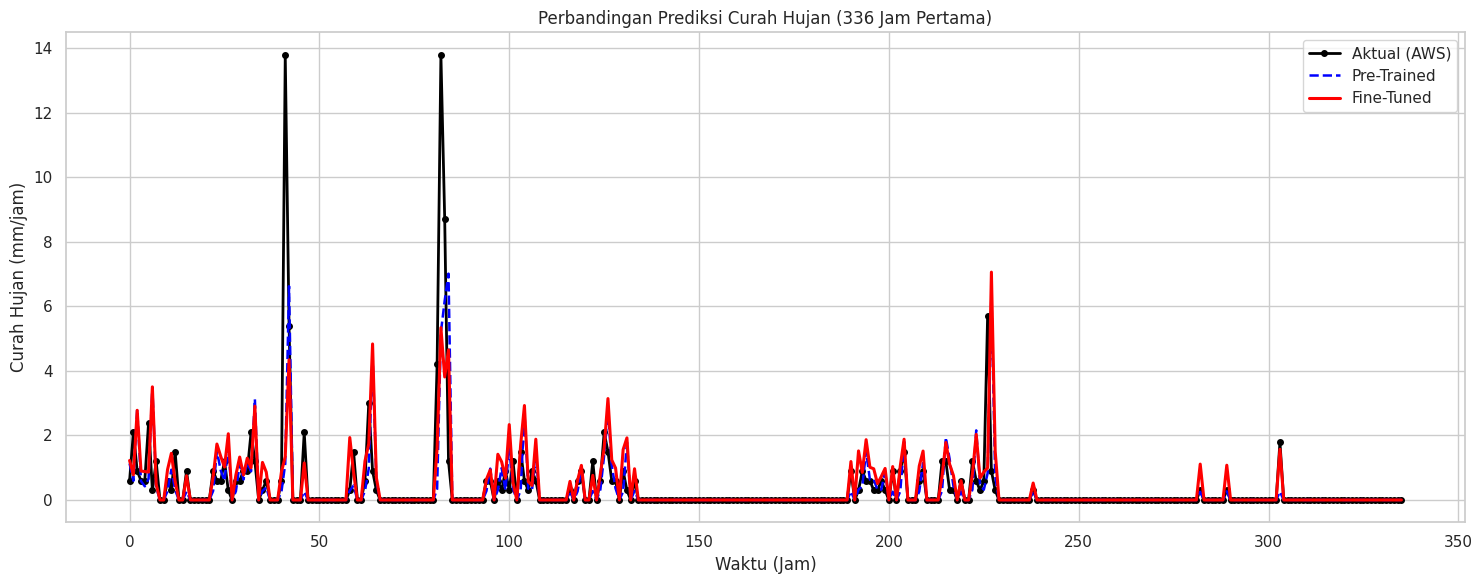

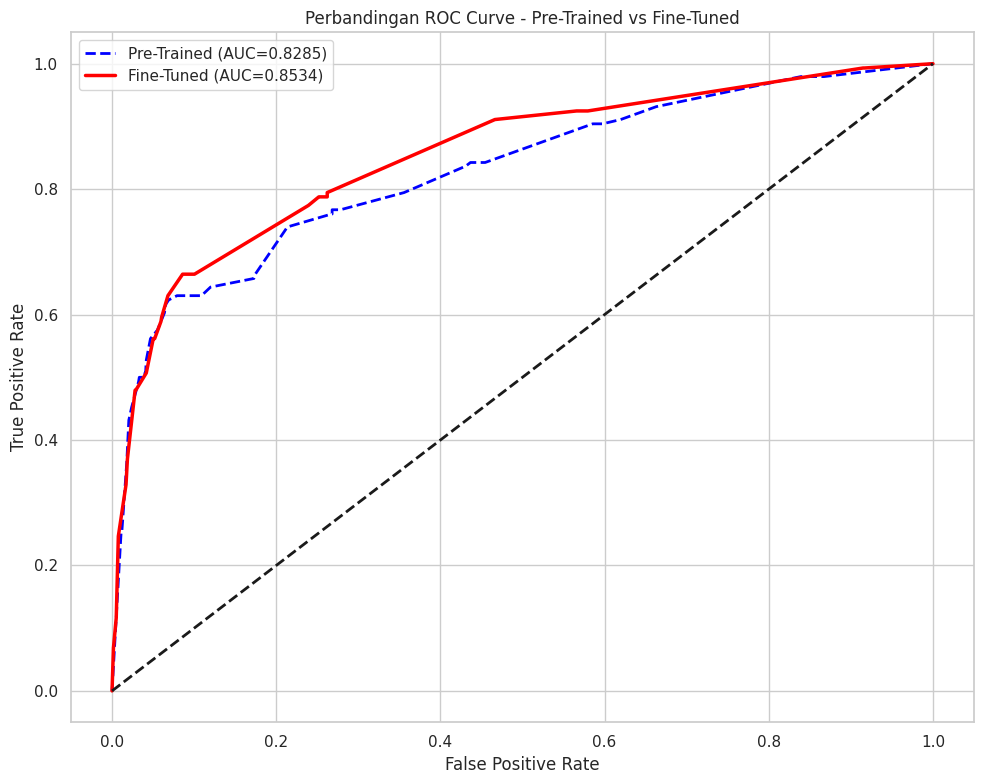

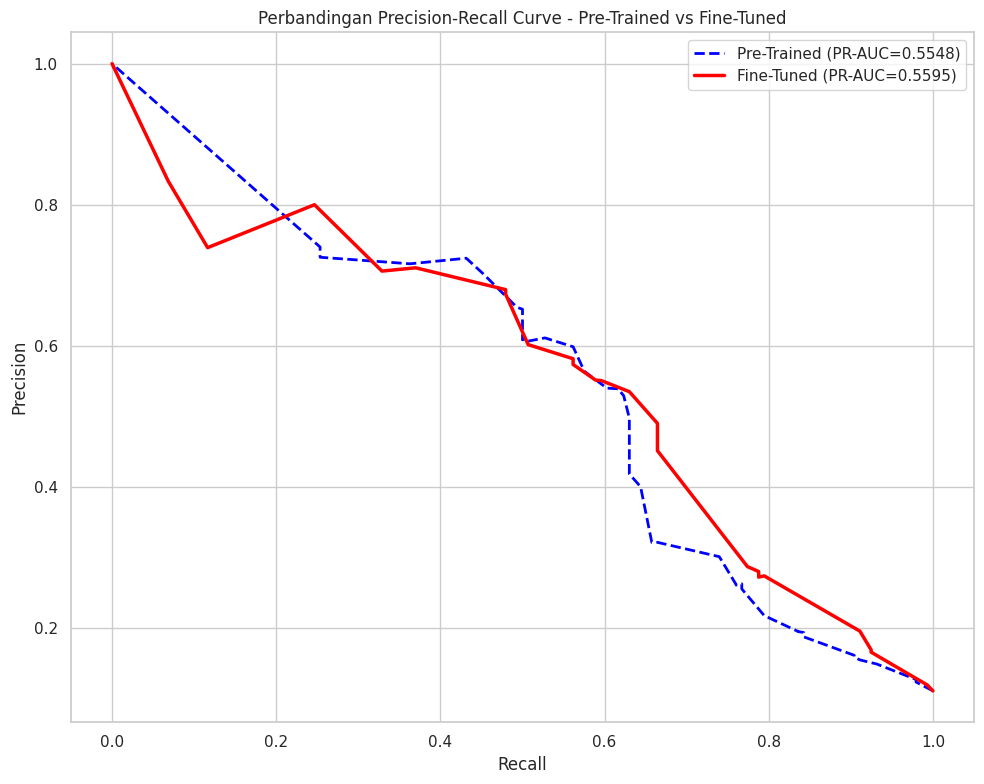

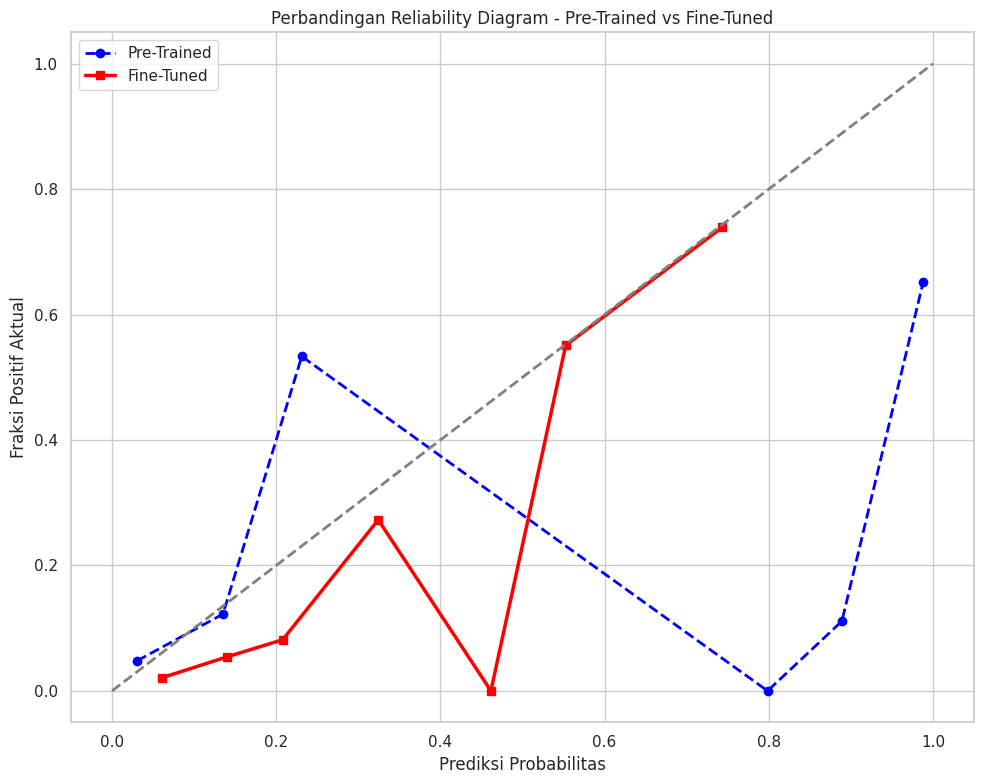

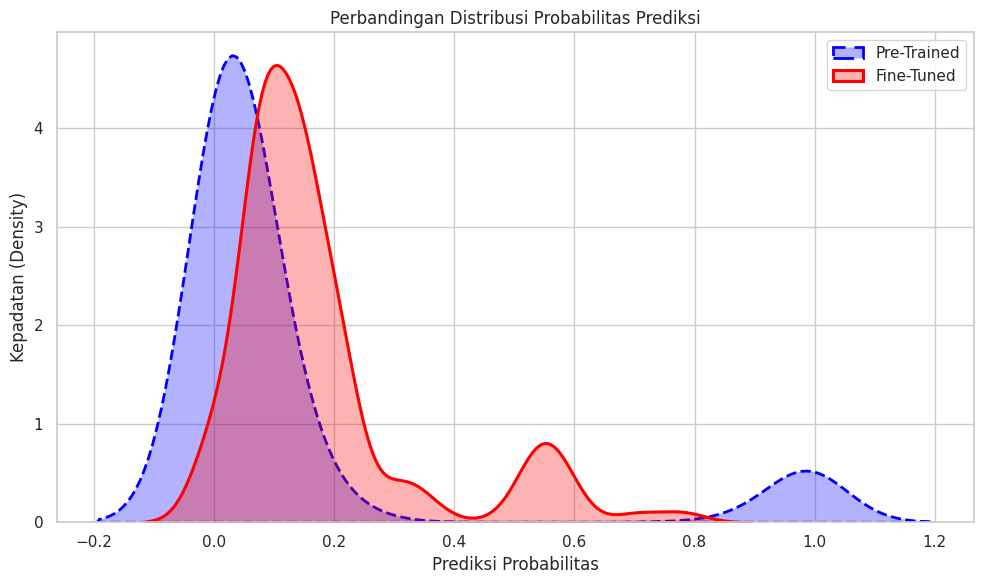

2026-07-16 06:00:57,364 - INFO - Perbandingan Model Selesai!


In [18]:
# Bab 3: Perbandingan Model (XGBoost)
logger.info("Memulai Bab 3: Perbandingan Model...")
comp_dir = BASE_OUTPUT_DIR / 'comparison'
comp_dir.mkdir(parents=True, exist_ok=True)

# Hitung prediksi pre-trained pada data uji AWS untuk perbandingan yang setara
pre_test_prob_uncal_comp = clf_pretrain.predict_proba(X_test)[:, 1]
pre_test_prob_cal_comp = apply_calibrator(calibrator_pre, cal_method_pre, pre_test_prob_uncal_comp)

pre_test_preds_r_comp = np.zeros(len(y_test_occ))
rainy_te = y_test_occ == 1
if reg_pretrain is not None and np.sum(rainy_te) > 0:
    pre_test_preds_r_comp[rainy_te] = reg_pretrain.predict(X_test[rainy_te])

# 1. Perbandingan Prediksi Kuantitas Hujan (Timeseries 336 Jam)
plt.figure(figsize=(15, 6))
start_idx = 0
end_idx = min(336, len(y_test_reg))
plt.plot(y_test_reg.values[start_idx:end_idx], label='Aktual (AWS)', color='black', marker='o', linewidth=2.0, markersize=4)
plt.plot(pre_test_preds_r_comp[start_idx:end_idx], label='Pre-Trained', color='blue', linestyle='--', linewidth=1.8)
plt.plot(test_preds_r[start_idx:end_idx], label='Fine-Tuned', color='red', linestyle='-', linewidth=2.2)
plt.title('Perbandingan Prediksi Curah Hujan (336 Jam Pertama)')
plt.xlabel('Waktu (Jam)')
plt.ylabel('Curah Hujan (mm/jam)')
plt.legend()
plt.tight_layout()
plt.savefig(comp_dir / 'prediction_comparison.png', dpi=300)
plt.show()
plt.close()

# 2. Perbandingan ROC Curve
plt.figure(figsize=(10, 8))
fpr_pre, tpr_pre, _ = roc_curve(y_test_occ, pre_test_prob_cal_comp)
fpr_post, tpr_post, _ = roc_curve(y_test_occ, test_probs_cal)
plt.plot(fpr_pre, tpr_pre, label=f'Pre-Trained (AUC={auc(fpr_pre, tpr_pre):.4f})', color='blue', linestyle='--', linewidth=2.0)
plt.plot(fpr_post, tpr_post, label=f'Fine-Tuned (AUC={auc(fpr_post, tpr_post):.4f})', color='red', linestyle='-', linewidth=2.5)
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Perbandingan ROC Curve - Pre-Trained vs Fine-Tuned')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(comp_dir / 'roc_comparison.png', dpi=300)
plt.show()
plt.close()

# 3. Perbandingan Precision-Recall Curve
plt.figure(figsize=(10, 8))
prec_pre, rec_pre, _ = precision_recall_curve(y_test_occ, pre_test_prob_cal_comp)
prec_post, rec_post, _ = precision_recall_curve(y_test_occ, test_probs_cal)
plt.plot(rec_pre, prec_pre, label=f'Pre-Trained (PR-AUC={auc(rec_pre, prec_pre):.4f})', color='blue', linestyle='--', linewidth=2.0)
plt.plot(rec_post, prec_post, label=f'Fine-Tuned (PR-AUC={auc(rec_post, prec_post):.4f})', color='red', linestyle='-', linewidth=2.5)
plt.title('Perbandingan Precision-Recall Curve - Pre-Trained vs Fine-Tuned')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.savefig(comp_dir / 'precision_recall_comparison.png', dpi=300)
plt.show()
plt.close()

# 4. Perbandingan Reliability Diagram (Calibration Curve)
plt.figure(figsize=(10, 8))
prob_true_pre, prob_pred_pre = calibration_curve(y_test_occ, pre_test_prob_cal_comp, n_bins=10)
prob_true_post, prob_pred_post = calibration_curve(y_test_occ, test_probs_cal, n_bins=10)
plt.plot(prob_pred_pre, prob_true_pre, marker='o', label='Pre-Trained', color='blue', linestyle='--', linewidth=2.0)
plt.plot(prob_pred_post, prob_true_post, marker='s', label='Fine-Tuned', color='red', linestyle='-', linewidth=2.5)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Perbandingan Reliability Diagram - Pre-Trained vs Fine-Tuned')
plt.xlabel('Prediksi Probabilitas')
plt.ylabel('Fraksi Positif Aktual')
plt.legend()
plt.tight_layout()
plt.savefig(comp_dir / 'reliability_comparison.png', dpi=300)
plt.show()
plt.close()

# 5. Perbandingan Probability Distribution
plt.figure(figsize=(10, 6))
sns.kdeplot(pre_test_prob_cal_comp, label='Pre-Trained', color='blue', linestyle='--', linewidth=2.0, fill=True, alpha=0.3)
sns.kdeplot(test_probs_cal, label='Fine-Tuned', color='red', linestyle='-', linewidth=2.2, fill=True, alpha=0.3)
plt.title('Perbandingan Distribusi Probabilitas Prediksi')
plt.xlabel('Prediksi Probabilitas')
plt.ylabel('Kepadatan (Density)')
plt.legend()
plt.tight_layout()
plt.savefig(comp_dir / 'probability_distribution_comparison.png', dpi=300)
plt.show()
plt.close()

logger.info("Perbandingan Model Selesai!")


## Analisis SHAP (*Feature Importance*)

Menghasilkan visualisasi *Game Theory* (SHAP) untuk membongkar kotak hitam (*blackbox*) model. Grafik ini menunjukkan **variabel mana yang paling kuat pengaruhnya** (misal: *CAPE* atau *Kelembaban*) dalam memicu prediksi hujan lebat.

2026-07-16 06:00:57,526 - INFO - Membangkitkan plot SHAP untuk Model XGBoost...


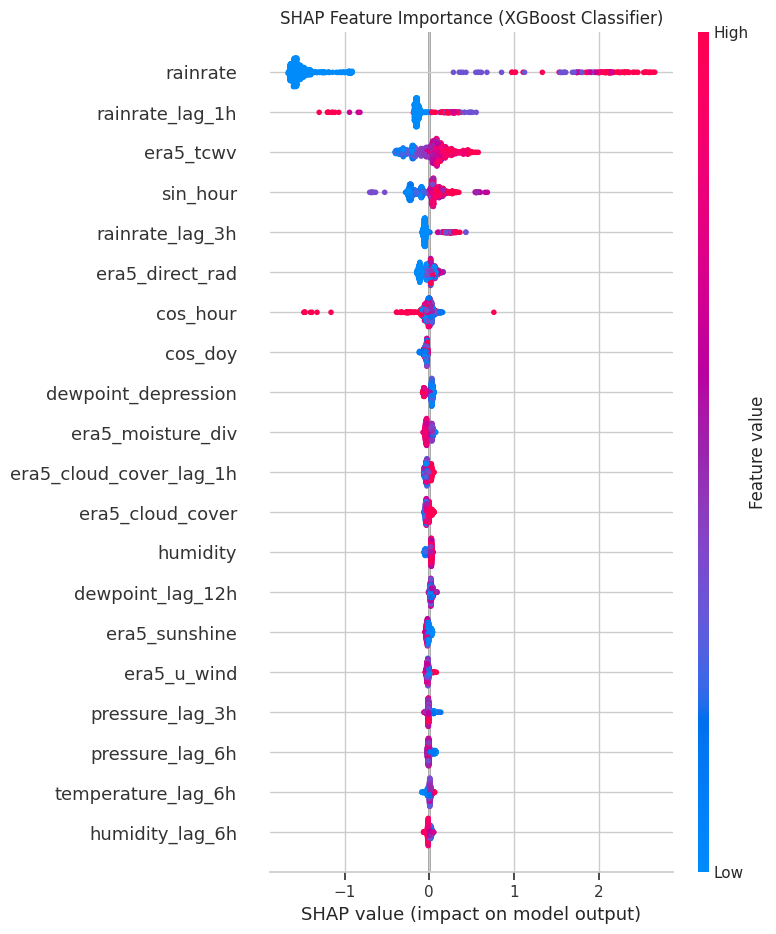

2026-07-16 06:01:16,429 - INFO - Plot SHAP berhasil disimpan!


In [19]:
# Sel Terakhir: Analisis SHAP (Feature Importance)
import shap
import matplotlib.pyplot as plt

logger.info("Membangkitkan plot SHAP untuk Model XGBoost...")

# Gunakan TreeExplainer yang sangat cepat untuk XGBoost
explainer = shap.TreeExplainer(clf_best)
# Ambil sampel dari Test Set untuk efisiensi
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Feature Importance (XGBoost Classifier)')
plt.tight_layout()
plt.savefig(evaluator.dirs['plots'] / 'shap_summary_clf.png', dpi=300)
plt.show()

logger.info("Plot SHAP berhasil disimpan!")
